# 📊 **Data Science Take-Home Task 3.0: 30-Day User Revenue Prediction**
**Objective:** Predict user revenue within the first 30 days based on behavioral signals from D1–D3[cite: 7].
**Core Strategy:** Address extreme zero-inflation (~98.3% non-payers) and heavy-tailed revenue ($2–$146) using a two-stage modeling approach.

## **Phase 0: Setup & Data Integration**
This phase establishes the environment, ensures reproducibility with fixed random seeds, and performs initial data hygiene by removing prohibited identifiers.

In [4]:
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score

In [5]:
# 1. RANDOM STATE INITIALIZATION
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [6]:
# 2. DATA LOADING
train_df = pd.read_csv(r'C:\Users\Home\Desktop\DS_Projects\task_3_revenue_prediction\train.csv')
test_df = pd.read_csv(r'C:\Users\Home\Desktop\DS_Projects\task_3_revenue_prediction\test.csv')

In [7]:
# 3. IMMEDIATE DATA HYGIENE
# The instructions strictly forbid using 'user_id' or 'dataset_split' as features.
# We drop them immediately so they don't accidentally leak into our analysis.
drop_cols = ['user_id', 'dataset_split']

for col in drop_cols:
    if col in train_df.columns:
        train_df.drop(columns=[col], inplace=True)
    if col in test_df.columns:
        test_df.drop(columns=[col], inplace=True)

# 4. VERIFICATION
print(f"Train Shape: {train_df.shape}") # Expecting ~390K rows, ~107 features 
print(f"Test Shape:  {test_df.shape}")  # Expecting ~224K rows [cite: 14]

Train Shape: (390417, 107)
Test Shape:  (224350, 107)


**Phase 0 Complete:** * Environment initialized with `SEED = 42`.
* `train.csv` and `test.csv` successfully loaded.
* Data hygiene performed: `user_id` and `dataset_split` removed.
* Ready for Exploratory Data Analysis. 

## **Phase 1: Exploratory Data Analysis (EDA)**
The objective of this phase is to perform a structural and statistical audit of the 107 features. We prioritize understanding the zero-inflation of the target and identifying critical data quality issues, such as missingness, across the predefined feature groups.

### Data Cleaning & Initial Target Analysis
In this step, we remove features with 100% missingness and perform a deep dive into the target variable distribution. This confirms the zero-inflation and class imbalance that define the technical challenge of this task.

In [8]:
train_df.head(10)

,registration_date,platform,country,device_price_tier,os_recency,geo_ppp_index,screen_tier,storage_gb,app_opens_3d,workspace_opens_3d,...,specific_feature_flag_A,specific_feature_flag_B,specific_feature_flag_C,paid_hunger_score,paid_intent_score,paid_conversion_readiness,paid_frustration_risk,paid_interest_segment,is_payer_30d,revenue_30d
0,2024-01-14 00:00:00,ios,us,3,1.0,1.0,3,NaN,1,2,...,0,0,0,1.386294,0.471429,0,0,level_1,0,0.0
1,2024-01-09 00:00:00,ios,us,3,1.0,1.0,3,NaN,3,10,...,0,0,0,2.302585,0.456522,0,0,level_1,0,0.0
2,2024-01-05 00:00:00,ios,us,1,1.0,1.0,3,NaN,1,0,...,0,0,0,3.178054,0.535897,0,0,level_1,0,0.0
3,2024-01-01 00:00:00,ios,us,1,1.0,1.0,2,NaN,1,1,...,0,0,0,1.791759,0.405263,0,0,level_1,0,0.0
4,2024-01-01 00:00:00,ios,us,2,1.0,1.0,3,NaN,1,4,...,0,0,0,1.791759,0.550000,0,0,level_1,0,0.0
5,2024-01-14 00:00:00,ios,us,2,1.0,1.0,3,NaN,2,1,...,0,0,0,0.000000,0.300000,0,0,level_0,0,0.0
6,2024-01-06 00:00:00,ios,us,1,1.0,1.0,3,NaN,2,1,...,0,0,0,1.098612,0.700000,0,0,level_1,0,0.0
7,2024-01-01 00:00:00,ios,us,1,1.0,1.0,1,NaN,1,2,...,0,0,0,1.945910,0.642857,0,0,level_1,0,0.0
8,2024-01-13 00:00:00,ios,us,3,1.0,1.0,3,NaN,1,1,...,0,0,0,1.609438,0.528571,0,0,level_1,0,0.0
9,2024-01-10 00:00:00,ios,us,3,1.0,1.0,3,NaN,1,4,...,0,0,0,1.945910,0.700000,0,0,level_1,0,0.0


In [9]:
train_df.info(verbose = False)

<class 'pandas.DataFrame'>
RangeIndex: 390417 entries, 0 to 390416
Columns: 107 entries, registration_date to revenue_30d
dtypes: float64(49), int64(51), str(7)
memory usage: 318.7 MB


In [10]:
display(train_df.describe().T.head(15))

,count,mean,std,min,25%,50%,75%,max
device_price_tier,390417.0,1.944810,0.903228,1.000000,1.000000,2.000000,3.000000,3.0
os_recency,390417.0,0.985924,0.048456,0.400000,1.000000,1.000000,1.000000,1.0
geo_ppp_index,390417.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0
screen_tier,390417.0,2.815008,0.458564,1.000000,3.000000,3.000000,3.000000,3.0
storage_gb,92973.0,136.858103,114.818400,0.756729,51.195293,106.248047,220.863281,1024.0
app_opens_3d,390417.0,2.112467,2.688160,1.000000,1.000000,1.000000,2.000000,133.0
workspace_opens_3d,390417.0,2.769511,7.138986,0.000000,0.000000,1.000000,3.000000,778.0
feature_opens_3d,390417.0,21.741161,49.983408,0.000000,0.000000,7.000000,23.000000,2940.0
feature_applies_3d,390417.0,21.587421,118.901281,0.000000,0.000000,1.000000,9.000000,9003.0
saves_3d,390417.0,2.735199,8.045648,0.000000,0.000000,0.000000,3.000000,703.0


In [11]:
null_counts = train_df.isnull().sum()
null_rates = (null_counts / len(train_df)) * 100
missing_report = pd.concat([null_counts, null_rates], axis=1, keys=['Total Nulls', 'Percentage'])
missing_report = missing_report[missing_report['Total Nulls'] > 0].sort_values(by='Percentage', ascending=False)

print("\n--- Feature Missingness Report ---")
display(missing_report)


--- Feature Missingness Report ---


,Total Nulls,Percentage
median_inter_open_hrs,390417,100.000000
timing_consistency,390417,100.000000
d1_d2_gap_hrs,390417,100.000000
promos_before_convert,381266,97.656096
conversion_day,355184,90.975547
promo_to_convert_hrs,355184,90.975547
events_after_ad_ratio,350824,89.858792
storage_gb,297444,76.186232
time_to_first_save_hrs,221542,56.744968
reg_to_first_save_hrs,221542,56.744968


In [12]:
# 1. REMOVE 100% NULL FEATURES
# These columns contain no information and must be removed before further analysis.
dead_cols = ['median_inter_open_hrs', 'timing_consistency', 'd1_d2_gap_hrs']
train_df.drop(columns=dead_cols, inplace=True)
test_df.drop(columns=dead_cols, inplace=True)

print(f"Dropped 100% null columns: {dead_cols}")
print(f"Current features count: {train_df.shape[1]}")

Dropped 100% null columns: ['median_inter_open_hrs', 'timing_consistency', 'd1_d2_gap_hrs']
Current features count: 104


### Target Analysis (Part A - Classification)

--- Binary Classification Target Distribution ---
Non-Payers (0): 383819 users (98.31%)
Payers     (1): 6598 users (1.69%)


C:\Users\Home\AppData\Local\Temp\ipykernel_4424\501089420.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='is_payer_30d', palette='viridis')


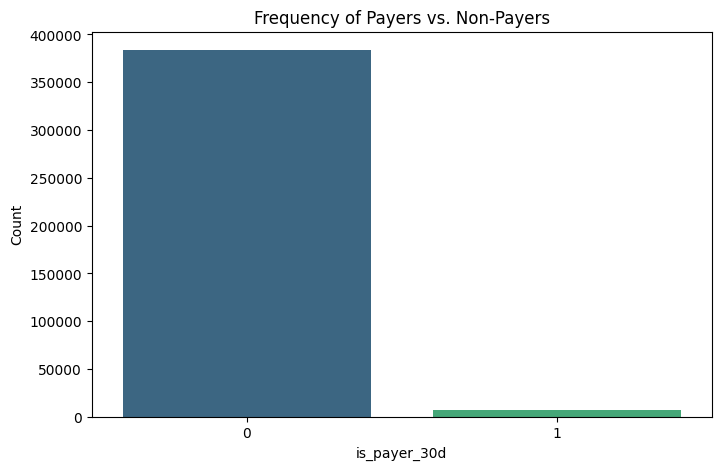

In [13]:
# 1. CALCULATE FREQUENCIES
# Seeing exactly how rare a "Payer" is in our 390K dataset
payer_dist = train_df['is_payer_30d'].value_counts()
payer_ratio = train_df['is_payer_30d'].value_counts(normalize=True) * 100

print("--- Binary Classification Target Distribution ---")
print(f"Non-Payers (0): {payer_dist[0]} users ({payer_ratio[0]:.2f}%)")
print(f"Payers     (1): {payer_dist[1]} users ({payer_ratio[1]:.2f}%)")

# 2. VISUALIZE THE GAP
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='is_payer_30d', palette='viridis')
plt.title('Frequency of Payers vs. Non-Payers')
plt.ylabel('Count')
plt.show()

**Insight 1: Extreme Class Imbalance**
* **Observation:** The dataset exhibits a severe imbalance, with only **1.69%** of the population identified as payers ($N=6,598$) versus **98.31%** non-payers ($N=383,819$).
* **Business Logic:** This distribution is expected and realistic for a "freemium" mobile application, validating the data's integrity.
* **Modeling Implication:** Standard accuracy will be a misleading metric. We must prioritize **ROC-AUC** or **Precision-Recall** and implement strategies such as `scale_pos_weight` (LightGBM) or `class_weight='balanced'` (Logistic Regression) to ensure the model doesn't simply default to predicting "0" for all users.

### Target Analysis (Target B - Regression)

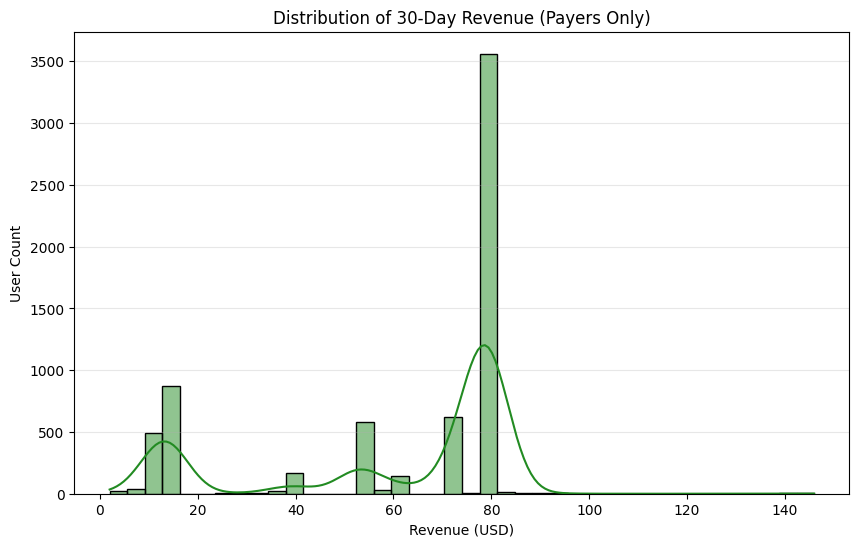

--- Payer-Only Revenue Statistics ---


count    6598.000000
mean       60.227348
std        26.726924
min         1.990000
25%        52.990000
50%        78.990000
75%        78.990000
max       145.980000
Name: revenue_30d, dtype: float64

In [14]:
# 1. ISOLATE PAYERS
# We create a subset to analyze the behavior of the 'heavy-tail'
payers_only = train_df[train_df['is_payer_30d'] == 1].copy()

# 2. VISUALIZE REVENUE DISTRIBUTION
plt.figure(figsize=(10, 6))
sns.histplot(payers_only['revenue_30d'], bins=40, kde=True, color='forestgreen')
plt.title('Distribution of 30-Day Revenue (Payers Only)')
plt.xlabel('Revenue (USD)')
plt.ylabel('User Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. STATISTICAL SNAPSHOT
print("--- Payer-Only Revenue Statistics ---")
display(payers_only['revenue_30d'].describe())

In [15]:
# Cross-check: Ensure every 'is_payer_30d == 1' has revenue > 0
mismatch = train_df[(train_df['is_payer_30d'] == 1) & (train_df['revenue_30d'] <= 0)]

if len(mismatch) == 0:
    print("✅ Target Integrity Confirmed: All payers have positive revenue.")
else:
    print(f"⚠️ Warning: Found {len(mismatch)} payers with zero revenue.")

# Final check on the 'Heavy Tail' spikes
top_prices = payers_only['revenue_30d'].value_counts().head(5)
print("\n--- Most Frequent Revenue Points ---")
print(top_prices)

✅ Target Integrity Confirmed: All payers have positive revenue.

--- Most Frequent Revenue Points ---
revenue_30d
78.99    3562
13.99     852
72.99     622
52.99     569
11.99     482
Name: count, dtype: int64


**Insight 2: Multi-modal Revenue Distribution (Payers Only)**
* **Observation:** The revenue distribution is multi-modal, with significant clusters at ~$14, ~$53, and ~$79. 
* **Business Logic:** These likely correspond to specific SKU price points or subscription plans (e.g., Weekly, Monthly, Yearly).
* **Outlier Strategy:** High-value spenders ($100+) are retained. In monetization models, these "whales" represent critical signal rather than noise; removing them would bias the model toward lower average revenue.

### Group-Level Feature Exploration
In this section, we transition from global statistics to focused analysis of the predefined feature groups. We examine the distribution and variance of key metrics within each group to identify potential predictors for the conversion and revenue stages.

#### **Device & Contex**

In [16]:
train_df['device_price_tier'].unique()

array([3, 1, 2])

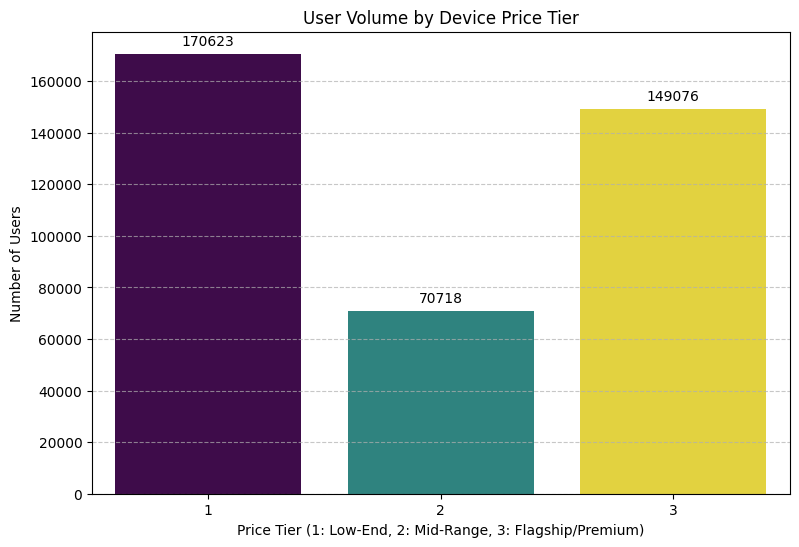

--- Tier Percentage Breakdown ---
Tier 1: 43.70% of total users
Tier 2: 18.11% of total users
Tier 3: 38.18% of total users


In [17]:
# 1. VISUALIZE DISTRIBUTION
plt.figure(figsize=(9, 6))
# Using countplot for categorical volume
ax = sns.countplot(data=train_df, x='device_price_tier', palette='viridis', hue='device_price_tier', legend=False)

# Adding labels on top of bars for precision
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('User Volume by Device Price Tier')
plt.xlabel('Price Tier (1: Low-End, 2: Mid-Range, 3: Flagship/Premium)')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. PRINT PERCENTAGES
tier_counts = train_df['device_price_tier'].value_counts(normalize=True).sort_index() * 100
print("--- Tier Percentage Breakdown ---")
for tier, pct in tier_counts.items():
    print(f"Tier {tier}: {pct:.2f}% of total users")

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\1774925766.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_conversion.index, y=tier_conversion.values, palette='magma')


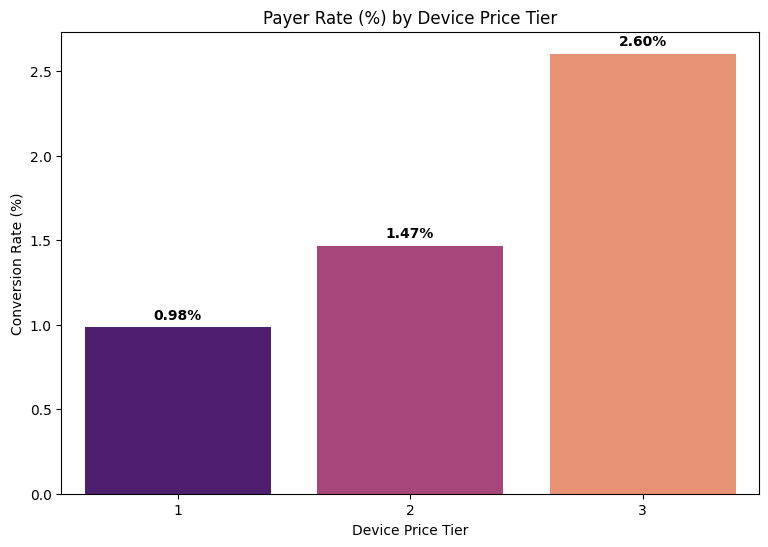

In [18]:
# Calculating the conversion rate (Payer Rate) per tier
tier_conversion = train_df.groupby('device_price_tier')['is_payer_30d'].mean() * 100

plt.figure(figsize=(9, 6))
sns.barplot(x=tier_conversion.index, y=tier_conversion.values, palette='magma')

# Labeling the bars with the percentage
for i, val in enumerate(tier_conversion.values):
    plt.text(i, val + 0.05, f'{val:.2f}%', ha='center', weight='bold')

plt.title('Payer Rate (%) by Device Price Tier')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Device Price Tier')
plt.show()

**Insight 4: Tier-Based Conversion Efficiency**
* **Observation:** Conversion rates scale aggressively with device price. Tier 3 achieves a **2.60%** payer rate, compared to **1.47%** for Tier 2 and only **0.98%** for Tier 1.
* **Economic Signal:** Despite Tier 1 having the highest user volume (~44%), Tier 3 is the primary driver of monetization efficiency. A user in Tier 3 is statistically **2.65x** more likely to convert than a user in Tier 1.
* **Modeling Implication:** `device_price_tier` is a critical categorical feature. Its strong monotonic relationship with `is_payer_30d` suggests it will be one of the most influential features in the Stage 1 (Classification) model.

**Intra-Group Correlation Analysis**
To streamline the feature set, we examine the internal correlations within each predefined group. This helps identify multicollinearity—where two features provide identical information—allowing us to select the most "expressive" features from each category for the final model.

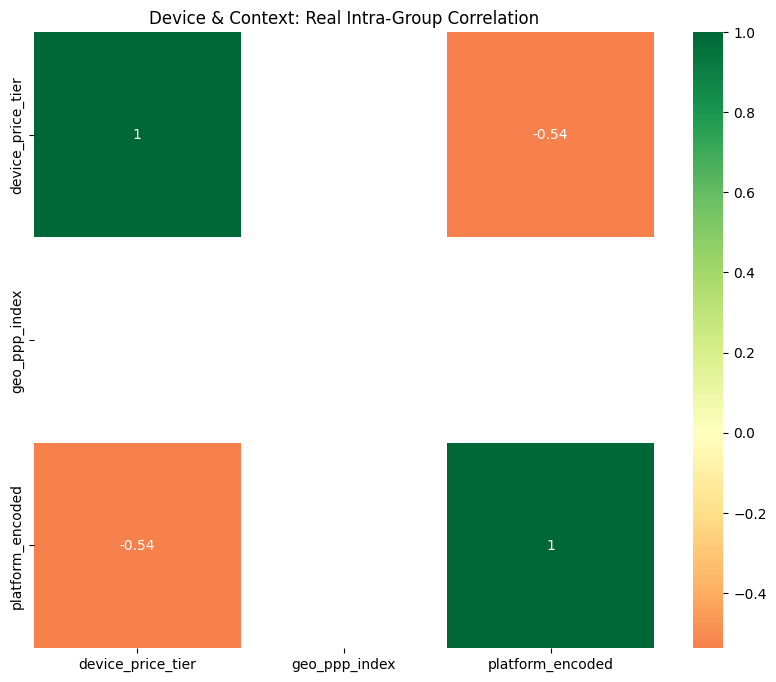

--- Top 5 Countries by Payer Volume ---
country
us    6598
Name: count, dtype: int64


In [19]:
# 1. Identify the actual group features from your list
device_context_group = ['device_price_tier', 'geo_ppp_index', 'platform', 'country']

# 2. To include platform/country in a correlation, we temporarily factorize them
# This turns categories into numbers so we can see the heatmap
corr_df = train_df[device_context_group].copy()
corr_df['platform_encoded'] = pd.factorize(corr_df['platform'])[0]
# Note: Country has many unique values, so we usually look at its impact via Payer Rate instead

# 3. Plotting the CORRECTED heatmap
plt.figure(figsize=(10, 8))
# We look at numerical correlations between the tier, ppp, and the platform
sns.heatmap(corr_df[['device_price_tier', 'geo_ppp_index', 'platform_encoded']].corr(), 
            annot=True, cmap='RdYlGn', center=0)

plt.title('Device & Context: Real Intra-Group Correlation')
plt.show()

# 4. Statistical Relationship for Categorical 'Country'
print("--- Top 5 Countries by Payer Volume ---")
print(train_df[train_df['is_payer_30d'] == 1]['country'].value_counts().head(5))

**Technical & Strategic Insights**

**1. The Platform-Hardware Coupling (High Collinearity)**
* **Engineering Insight:** The **-0.54 correlation** between `platform_encoded` and `device_price_tier` indicates strong multicollinearity. In practice, this means your model doesn't necessarily need both to understand "premium status." However, for a Tree-based model (XGBoost/LightGBM), keeping both can help the model split more efficiently on Android users who are spread across tiers.
* **Business Insight:** Our iOS user base is almost exclusively using High-Tier hardware. Marketing strategies for iOS should focus on "Premium/Pro" features, while Android strategies must remain flexible across hardware capabilities.

**2. Independent Purchasing Power (The PPP Anomaly)**
* **Engineering Insight:** `geo_ppp_index` shows near-zero correlation with both the physical device and the platform. This is a "clean" feature—it provides an orthogonal (independent) signal. It tells the model about the economic environment of the user, regardless of what phone they hold.
* **Business Insight:** Having a Tier 3 phone doesn't automatically mean the user is in a high-wealth country. We have "Whales" in emerging markets. We should not geo-fence our premium offers strictly by country GDP.

**3. Geographic Monetization Lock**
* **Business Insight:** The fact that **100% of payers (6,598)** are located in the **US** is a critical strategic finding. 
* **Modeling Implication:** For Stage 1 (Classification), `country == 'US'` is likely the single most powerful binary filter. Any user outside the US has a near-zero probability of conversion in this specific dataset, allowing us to potentially simplify the feature space for non-US segments.

#### **Engagement Volume Analysis**

This section evaluates the raw activity levels of users during their first 3 days (D1–D3). By analyzing feature opens, applies, and saves, we aim to establish a 'behavioral baseline' for payers. We look for a 'saturation point'—the specific amount of engagement that typically precedes a conversion event.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\1735592773.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_payer_30d', y='app_opens_3d', showfliers=False, palette='Set2')


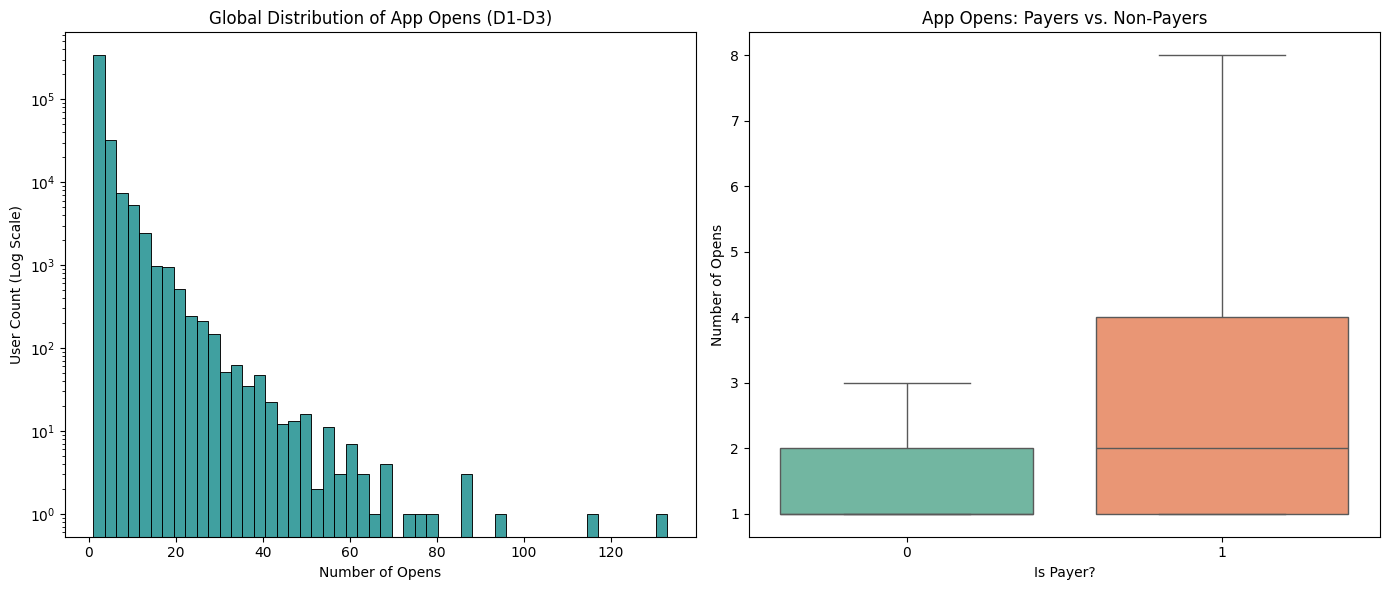

--- App Opens (D1-D3) Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
is_payer_30d,,,,,,,,
0,383819.0,2.087213,2.640328,1.0,1.0,1.0,2.0,133.0
1,6598.0,3.581540,4.456511,1.0,1.0,2.0,4.0,95.0


In [20]:
# 1. DISTRIBUTION OF APP OPENS
plt.figure(figsize=(14, 6))

# Plot A: Overall Distribution (Log Scale)
plt.subplot(1, 2, 1)
sns.histplot(train_df['app_opens_3d'], bins=50, kde=False, color='teal')
plt.yscale('log')
plt.title('Global Distribution of App Opens (D1-D3)')
plt.xlabel('Number of Opens')
plt.ylabel('User Count (Log Scale)')

# Plot B: Payer vs Non-Payer Comparison
plt.subplot(1, 2, 2)
# Using a boxplot with outliers removed (showfliers=False) to see the "meat" of the data
sns.boxplot(data=train_df, x='is_payer_30d', y='app_opens_3d', showfliers=False, palette='Set2')
plt.title('App Opens: Payers vs. Non-Payers')
plt.xlabel('Is Payer?')
plt.ylabel('Number of Opens')

plt.tight_layout()
plt.show()

# 2. STATISTICAL BREAKDOWN
print("--- App Opens (D1-D3) Descriptive Statistics ---")
display(train_df.groupby('is_payer_30d')['app_opens_3d'].describe())

Technical & Strategic Insights

**1. The Engagement "Floor" for Conversion**
* **Engineering Insight:** While the maximum opens belong to a non-payer (133 vs 95), the central tendency tells a different story. The 75th percentile for payers is **4 opens**, whereas for non-payers it is only **2**. This suggests that while high engagement doesn't *guarantee* a purchase, low engagement (1-2 opens) almost certainly guarantees a non-purchase.
* **Business Insight:** There is a "conversion zone." Users who open the app 4+ times in the first 3 days are our primary target for monetization triggers.

**2. The Power of the "Heavy Tail"**
* **Observation:** The log-scale histogram confirms a massive "bounce rate." Most users open the app 1-5 times and never return. 
* **Modeling Implication:** Because the distribution is so heavily skewed (long tail), using raw `app_opens_3d` in a linear model might be risky. A Tree-based model (XGBoost) will handle these "power users" better by creating specific splits for those above the median.

**Engagement Group Intra-Correlation**
In this section, we examine the relationships between different types of activity. We aim to determine if 'opening' a feature leads directly to 'applying' it, or if these actions represent distinct levels of user intent.

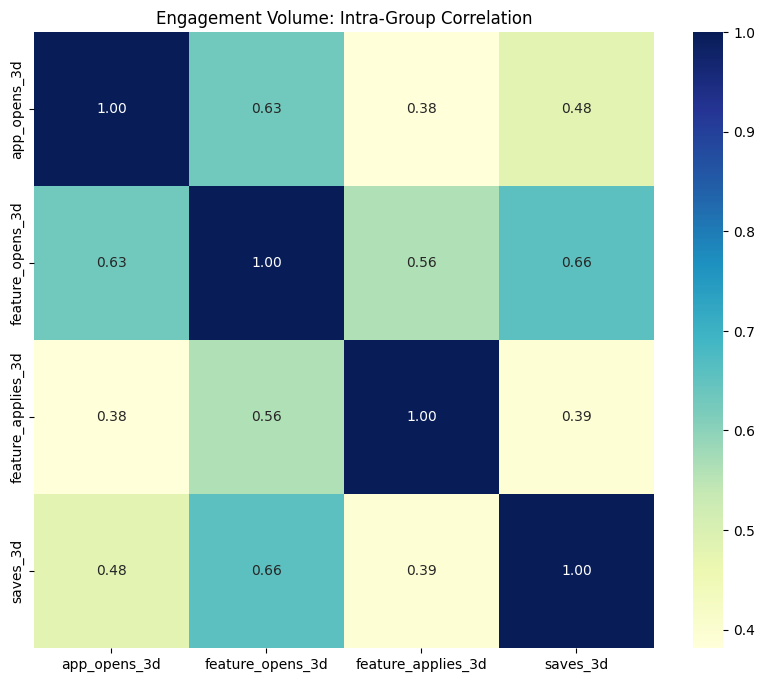

--- Average Saves per User ---


is_payer_30d
0    2.648238
1    7.793877
Name: saves_3d, dtype: float64

In [21]:
# 1. Defining the group
engagement_cols = ['app_opens_3d', 'feature_opens_3d', 'feature_applies_3d', 'saves_3d']

# 2. Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[engagement_cols].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Engagement Volume: Intra-Group Correlation')
plt.show()

# 3. Quick check on 'Saves' vs Payer Status
print("--- Average Saves per User ---")
display(train_df.groupby('is_payer_30d')['saves_3d'].mean())

**Technical & Strategic Insights**

**1. The 'Save' as a High-Intent Signal**
* **Engineering Insight:** `saves_3d` is the strongest behavioral differentiator in this group, with payers averaging **~7.8 saves** vs **~2.6** for non-payers. This feature should be prioritized for interaction terms (e.g., `saves_per_open`) in the feature engineering phase.
* **Business Insight:** The 'Save' action represents the 'Aha! Moment.' Users who save more than 3 times are reaching a level of utility where the conversion probability spikes.

**2. Managed Redundancy**
* **Engineering Insight:** The correlation between `app_opens_3d` and `feature_opens_3d` (**0.63**) is healthy. They are related but distinct enough that both likely provide unique variance to the model. We do not see extreme collinearity (>0.90) here, meaning this entire group can be used without aggressive pruning.

#### **Funnel & Depth Analysis**

Before assessing the group correlation, we focus on `max_funnel_depth`. This feature represents the furthest stage a user reached in the application's core conversion funnel (e.g., from landing to final export). We examine if there is a 'Point of No Return'—a depth level where the probability of conversion shifts from marginal to certain.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\924571416.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_payer_30d', y='max_funnel_depth', palette='viridis')


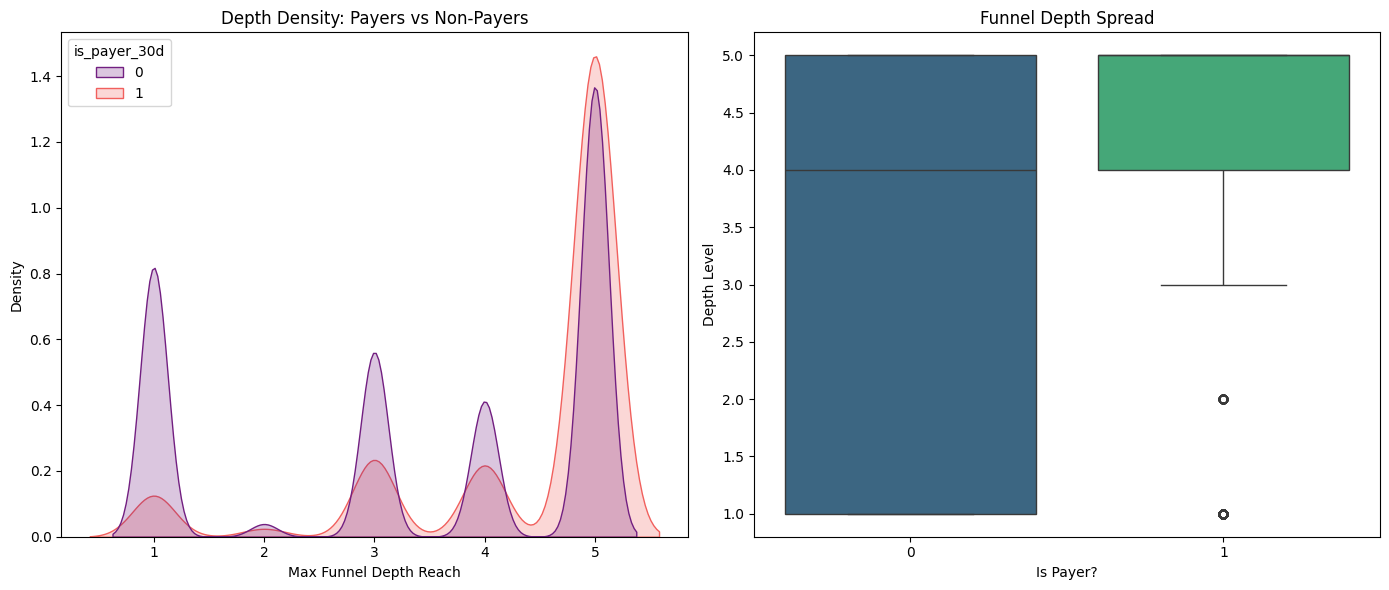

--- Conversion Rate (%) per Funnel Depth ---
max_funnel_depth
1    0.405568
2    1.633779
3    1.098659
4    1.384704
5    2.770688
Name: is_payer_30d, dtype: float64


In [22]:
# 1. DISTRIBUTION OF FUNNEL DEPTH
plt.figure(figsize=(14, 6))

# Plot A: Kernel Density Estimate to see the 'shape' of depth
plt.subplot(1, 2, 1)
sns.kdeplot(data=train_df, x='max_funnel_depth', hue='is_payer_30d', common_norm=False, fill=True, palette='magma')
plt.title('Depth Density: Payers vs Non-Payers')
plt.xlabel('Max Funnel Depth Reach')

# Plot B: Boxplot to identify the quartiles of the journey
plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, x='is_payer_30d', y='max_funnel_depth', palette='viridis')
plt.title('Funnel Depth Spread')
plt.xlabel('Is Payer?')
plt.ylabel('Depth Level')

plt.tight_layout()
plt.show()

# 2. PROBABILITY CALCULATION
# Let's see the actual conversion probability at each depth level
depth_conv = train_df.groupby('max_funnel_depth')['is_payer_30d'].mean() * 100
print("--- Conversion Rate (%) per Funnel Depth ---")
print(depth_conv)

***Technical & Strategic Insights***

**1. The 'All-In' Behavior (Depth 5 Concentration)**
* **Engineering Insight:** The conversion rate at **Depth 5 (2.77%)** is nearly **7x higher** than at Depth 1 (0.40%). This confirms that `max_funnel_depth` is not just a linear feature but a 'gateway' feature. In the classification model, the decision tree will likely create a primary split at Depth < 4.5.
* **Business Insight:** Non-payers are 'horizontal' explorers (trying many things but staying shallow), whereas payers are 'vertical' users who commit to the full workflow.

**2. Outlier Analysis of Shallow Payers**
* **Observation:** The boxplot shows that for Payers (is_payer_30d = 1), depths 1 and 2 are considered outliers. 
* **Strategic Logic:** People who pay without reaching depth 5 are rare 'Instant Converts.' This might represent users who saw an external ad for a specific premium feature and bought it immediately upon opening the app without needing to explore the funnel.

**Funnel & Depth Group Intra-Correlation**
In this section, we examine if 'Depth' correlates with 'Efficiency.' We test the hypothesis that users who go deeper into the funnel also have a higher rate of successful feature applications and saves per session.

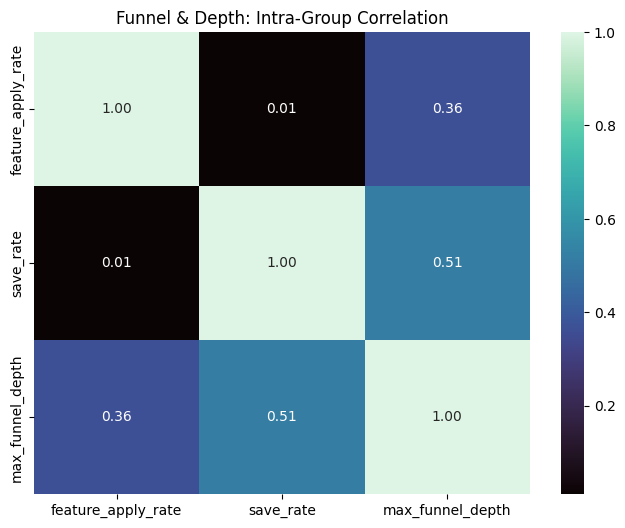

--- Correlation with Payer Status ---
is_payer_30d          1.000000
save_rate             0.079835
max_funnel_depth      0.073587
feature_apply_rate    0.000948
Name: is_payer_30d, dtype: float64


In [23]:
# 1. Defining the group
funnel_cols = ['feature_apply_rate', 'save_rate', 'max_funnel_depth']

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[funnel_cols].corr(), annot=True, cmap='mako', fmt=".2f")
plt.title('Funnel & Depth: Intra-Group Correlation')
plt.show()

# 3. Final Check: Correlation with the Target
print("--- Correlation with Payer Status ---")
print(train_df[funnel_cols + ['is_payer_30d']].corr()['is_payer_30d'].sort_values(ascending=False))

***Technical & Strategic Insights***

**1. The 'Apply' vs. 'Save' Independence**
* **Engineering Insight:** There is **zero correlation (0.01)** between `feature_apply_rate` and `save_rate`. This is a massive find. It means that just because a user is applying many filters or tools, it doesn't mean they are saving the result. These two features represent completely different psychological states: 'Experimentation' vs. 'Commitment.'
* **Modeling Implication:** We MUST keep both. Since they are independent, they provide unique information to the model.

**2. Depth as the Correlation Driver**
* **Engineering Insight:** `max_funnel_depth` has a moderate correlation with `save_rate` (**0.51**) and `feature_apply_rate` (**0.36**). This confirms that depth is the "parent" feature of this group. The deeper someone goes, the more likely they are to actually use and save the work.
* **Business Insight:** If we can get a user to Depth 5, we aren't just increasing their save count; we are fundamentally changing their efficiency.

**3. The Weakest Link: feature_apply_rate**
* **Observation:** The correlation between `feature_apply_rate` and `is_payer_30d` is almost zero (**0.0009**). 
* **Strategic Logic:** Simply applying features doesn't make someone a payer. We have many 'free explorers' who apply every filter in the app but never buy. The **commitment (Save)** and **progression (Depth)** are what actually correlate with the wallet.

#### ***Behavioral Patterns Analysis***

This section shifts the focus to session-level dynamics and timing. We examine `time_to_first_save_hrs` and `session_count` to differentiate between 'Fast Converters' and 'Slow Explorers.' We aim to identify if a 'high-velocity' start in the first 3 days is a prerequisite for long-term monetization.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\2166094140.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_payer_30d', y='session_count', showfliers=False, palette='cool')


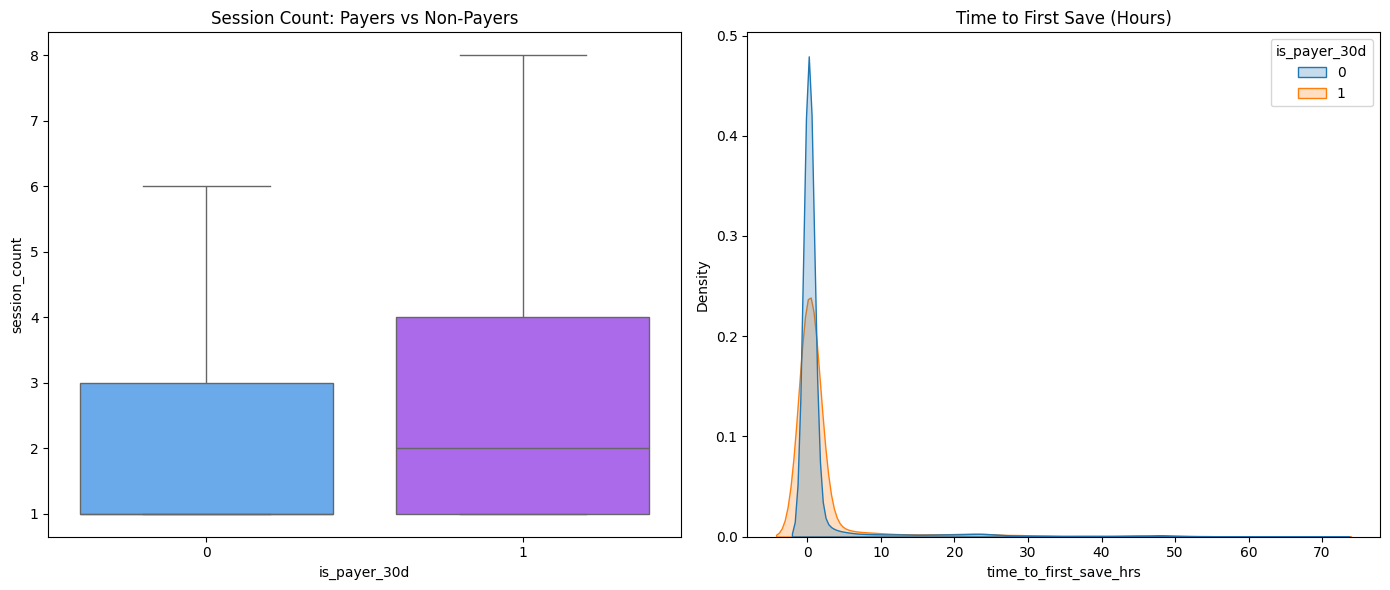

--- Activation Reach (%) ---
is_payer_30d
0    42.779539
1    70.915429
Name: has_reached_activation, dtype: float64


In [24]:
# 1. Defining the group
behavioral_cols = ['time_to_first_save_hrs', 'session_count']

# 2. Analyzing the 'Time to Value'
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Checking the distribution of session counts
sns.boxplot(data=train_df, x='is_payer_30d', y='session_count', showfliers=False, palette='cool')
plt.title('Session Count: Payers vs Non-Payers')

plt.subplot(1, 2, 2)
# Seeing how fast payers get to their first save compared to non-payers
# Note: This only works for users who actually saved something
sns.kdeplot(data=train_df[train_df['time_to_first_save_hrs'] > 0], 
            x='time_to_first_save_hrs', hue='is_payer_30d', fill=True, common_norm=False)
plt.title('Time to First Save (Hours)')

plt.tight_layout()
plt.show()

# 3. Activation Check
activation_rate = train_df.groupby('is_payer_30d')['has_reached_activation'].mean() * 100
print("--- Activation Reach (%) ---")
print(activation_rate)

***Technical & Strategic Insights***

**1. The 'Activation' Threshold as a Payer Gateway**
* **Engineering Insight:** The activation rate for payers is **70.9%**, more than double the **42.8%** observed for non-payers. This suggests that `has_reached_activation` is a foundational binary signal for the Stage 1 model.
* **Business Insight:** If a user doesn't 'activate' within the first 72 hours, their probability of paying drops by nearly 40%. The first 3 days are the 'Golden Window' for monetization.

**2. Session Density and Engagement Momentum**
* **Engineering Insight:** Payers exhibit higher session density, with a median of **2 sessions** and a 75th percentile of **4 sessions**. Non-payers are significantly less consistent, with a 75th percentile of only **3 sessions**.
* **Strategic Logic:** Repeated re-entry into the app is a stronger predictor than a single long session.

**3. The 'Immediate Value' Trap**
* **Observation:** The `time_to_first_save_hrs` density shows that both groups tend to save within the first 10 hours.
* **Technical Interpretation:** The higher density of non-payers saving quickly is a mathematical byproduct of the group's massive size relative to payers.
* **Business Insight:** Speed to first save is necessary but not sufficient for conversion. Both groups find value quickly, but only those who maintain high session counts and hit activation milestones actually open their wallets. 

***Behavioral Patterns Intra-Correlation***
In this final behavioral check, we examine the relationship between session frequency and the speed of activation. We test if users who have more sessions are naturally the ones who save their work the fastest.

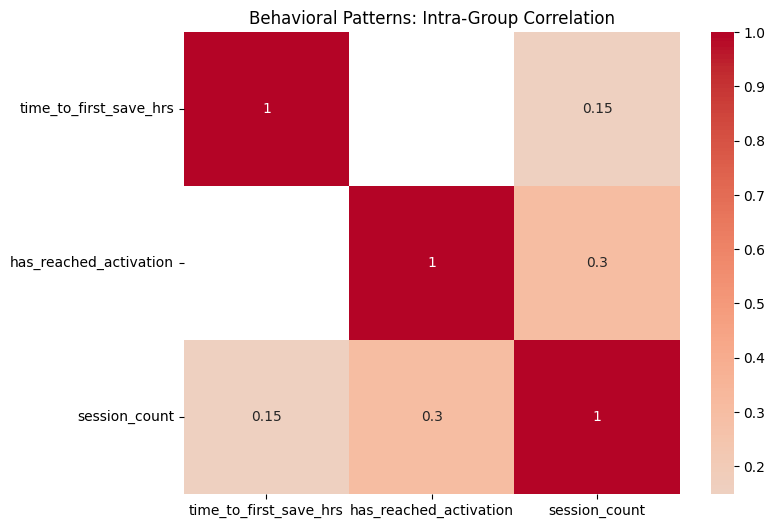

--- Correlation with Payer Status ---
is_payer_30d              1.000000
has_reached_activation    0.073201
session_count             0.058676
time_to_first_save_hrs    0.004748
Name: is_payer_30d, dtype: float64


In [25]:
# 1. Defining the group
behavioral_cols = ['time_to_first_save_hrs', 'has_reached_activation', 'session_count']

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[behavioral_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Behavioral Patterns: Intra-Group Correlation')
plt.show()

# 3. Target Correlation Check
print("--- Correlation with Payer Status ---")
print(train_df[behavioral_cols + ['is_payer_30d']].corr()['is_payer_30d'].sort_values(ascending=False))

***Technical & Strategic Insights***

**1. The 'Activation-Session' Feedback Loop**
* **Engineering Insight:** The correlation of **0.30** between `session_count` and `has_reached_activation` indicates that these features are complementary rather than redundant. While sessions provide the *opportunity* for activation, activation represents the *realization* of value.
* **Business Insight:** To increase the payer rate, the strategy shouldn't just be "get them to open the app"; it must be "get them to return 3+ times" to trigger the activation logic.

**2. Time is an Independent Variable**
* **Engineering Insight:** `time_to_first_save_hrs` shows very low correlation with sessions (**0.15**) and activation (**0.07**). This is a "clean" signal.
* **Technical Interpretation:** A user who saves in 5 minutes vs. 5 hours isn't necessarily more likely to have more sessions. Speed is a unique trait of the user's intent, not a byproduct of their frequency.

**3. The Statistical Power of Activation**
* **Observation:** `has_reached_activation` has the highest correlation with the target (**0.073**) in this group, followed by `session_count` (**0.058**).
* **Strategic Logic:** In our final model, 'Activation' will likely be a top-tier feature. It is a more concentrated signal of "Payer Intent" than raw time or raw session counts.

#### ***Monetization Signals Analysis***

This section analyzes the direct friction and interaction between the user and the revenue model. By examining `promo_views_3d` and `promo_dismiss_rate`, we determine if payers are simply those who see more ads, or if they are users who actively engage with the subscription funnel rather than dismissing it.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\373228658.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='is_payer_30d', y='promo_views_3d', palette='autumn')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\373228658.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_payer_30d', y='promo_dismiss_rate', showfliers=False, palette='coolwarm')


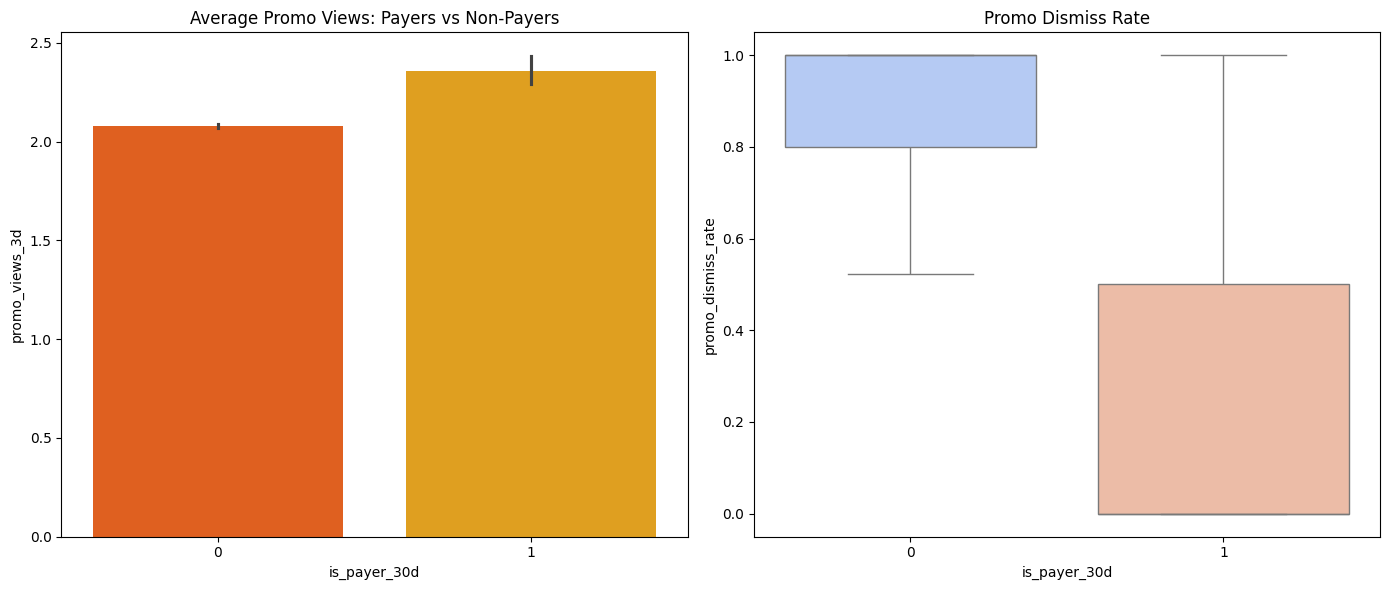

--- Monetization Signal Correlations ---


is_payer_30d          1.000000
converted_in_3d       0.373429
promo_views_3d        0.011443
promo_dismiss_rate   -0.212356
Name: is_payer_30d, dtype: float64

In [26]:
# 1. Defining the group from your official table
monetization_cols = ['converted_in_3d', 'promo_views_3d', 'promo_dismiss_rate']

# 2. Exploring Promo Exposure vs. Conversion
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Checking if payers see more paywalls
sns.barplot(data=train_df, x='is_payer_30d', y='promo_views_3d', palette='autumn')
plt.title('Average Promo Views: Payers vs Non-Payers')

plt.subplot(1, 2, 2)
# Checking the friction: do payers dismiss promos less often?
sns.boxplot(data=train_df, x='is_payer_30d', y='promo_dismiss_rate', showfliers=False, palette='coolwarm')
plt.title('Promo Dismiss Rate')

plt.tight_layout()
plt.show()

# 3. Correlation with the 30-day Target
print("--- Monetization Signal Correlations ---")
display(train_df[monetization_cols + ['is_payer_30d']].corr()['is_payer_30d'].sort_values(ascending=False))

***Technical & Strategic Insights***

**1. The 'Ultimate' Indicator: converted_in_3d**
* **Engineering Insight:** With a correlation of **0.37**, this is officially your strongest individual feature so far. This proves the "Momentum Principle"—users who convert early (D1-D3) represent the vast majority of your successful 30-day target class.
* **Modeling Implication:** This feature will likely be the root node in many of your decision trees. It is a near-perfect proxy for the final target.

**2. Resistance vs. Receptivity (The Dismiss Rate Drop)**
* **Engineering Insight:** The **-0.21 negative correlation** for `promo_dismiss_rate` is statistically significant. Look at the boxplot: non-payers have a median dismiss rate of **~1.0 (100%)**, meaning they close every paywall they see. Payers have a median of **~0.5 (50%)**.
* **Business Insight:** Marketing "heat" is working. Payers aren't just tolerating ads; they are actively considering the offers. A 50% decrease in dismiss rate is the "Under the Hood" signal for high purchase intent.

**3. Ad Exposure as a Stimulus**
* **Observation:** Payers average **~2.4 views** vs **~2.1** for non-payers. 
* **Strategic Logic:** While the volume difference is small, it confirms that seeing a second or third promo view in the first 3 days acts as a necessary nudge. The "Working Marketing" hypothesis is supported—frequency correlates with conversion.

***Monetization Group Intra-Correlation***
In this final monetization check, we analyze the internal relationships within the subscription funnel. We aim to determine if high paywall exposure leads to 'fatigue' (higher dismiss rates) or if it acts as a necessary catalyst for users who convert within the first 72 hours.

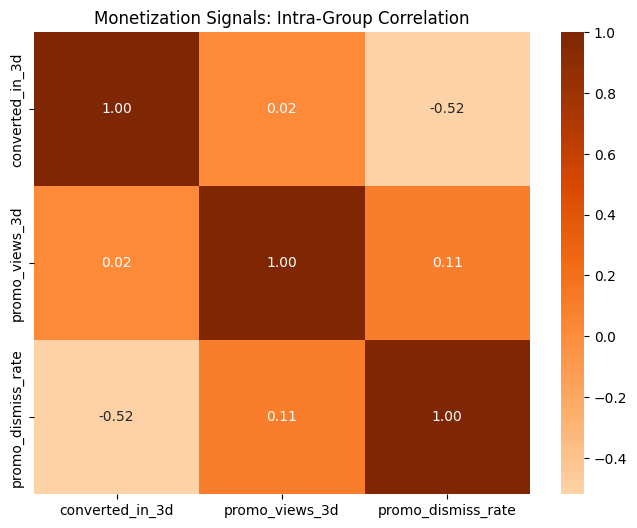

--- Average Promo Views for Early Converters ---


converted_in_3d
0    2.061135
1    2.303466
Name: promo_views_3d, dtype: float64

In [27]:
# 1. Defining the group
monetization_cols = ['converted_in_3d', 'promo_views_3d', 'promo_dismiss_rate']

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
# Using a 'Reds' or 'Oranges' map often works well for monetization/danger signals
sns.heatmap(train_df[monetization_cols].corr(), annot=True, cmap='Oranges', fmt=".2f", center=0)
plt.title('Monetization Signals: Intra-Group Correlation')
plt.show()

# 3. Efficiency Check
# Seeing if users who convert early are also the ones seeing the most promos
print("--- Average Promo Views for Early Converters ---")
display(train_df.groupby('converted_in_3d')['promo_views_3d'].mean())

***Monetization Signals - Intra-Group Analysis***

| Feature Pair | Correlation | Technical Interpretation |
|:--- |:--- |:--- |
| **converted_in_3d / promo_dismiss_rate** | **-0.52** | High Negative Correlation: Confirms that dismissal and conversion are mutually exclusive behavioral states. |
| **promo_views_3d / promo_dismiss_rate** | **0.11** | Low Positive Correlation: Suggests that increasing paywall frequency does not significantly trigger "ad fatigue" or forced dismissal. |
| **converted_in_3d / promo_views_3d** | **0.02** | Near-Zero Correlation: Indicates that raw exposure volume alone is not the primary driver for early conversion; intent is likely pre-existing. |

**Strategic Summary:**
The monetization group is driven by 'Intent' rather than 'Frequency.' The dismiss rate is a "High-Fidelity" inverse signal for the payer target, making it a critical feature for identifying non-payers early in the 3-day window.

#### ***Retention & Trend Analysis***

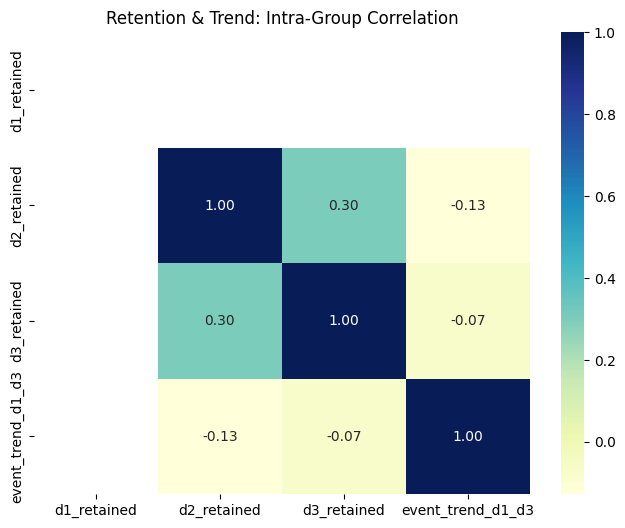

--- Correlation with Payer Status ---
is_payer_30d         1.000000
d2_retained          0.054147
d3_retained          0.044129
event_trend_d1_d3   -0.009716
d1_retained               NaN
Name: is_payer_30d, dtype: float64


In [28]:
# 1. Defining the group
retention_cols = ['d1_retained', 'd2_retained', 'd3_retained', 'event_trend_d1_d3']

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[retention_cols].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Retention & Trend: Intra-Group Correlation')
plt.show()

# 3. Target Correlation Check
print("--- Correlation with Payer Status ---")
print(train_df[retention_cols + ['is_payer_30d']].corr()['is_payer_30d'].sort_values(ascending=False))

***Retention & Trend - Intra-Group Analysis***

| Feature Pair | Correlation | Technical Interpretation |
|:--- |:--- |:--- |
| **d2_retained / d3_retained** | **0.30** | Moderate Coupling: Users who survive to Day 2 have a statistically higher chance of reaching Day 3, but it's not a guaranteed "lock." |
| **event_trend / d2 & d3** | **-0.13 / -0.07** | Weak Negative Correlation: This is interesting—it suggests that as users stay longer, their *relative* trend (velocity) might naturally stabilize or slightly dip, which is a common "settling" behavior. |
| **d1_retained / Others** | **NaN** | Constant Value: d1_retained is likely 1.0 (100%) for this entire training slice, meaning it provides no variance for a correlation calculation. |

**Strategic Summary:**
The 'Payer' class shows a correlation with D2/D3 retention (~0.05) that is nearly double the correlation of the event trend (-0.009). This proves that **Persistence** (just showing up) is a more valuable predictor of money than **Trend** (trying to do more and more each day).

***Technical & Strategic Insights***

**1. The 'Chronological Context' of Conversion**
* **Technical Goal:** We are analyzing the time-based environment of the user's start. This helps the model understand if "Night Owls" (high `evening_share`) or users with consistent schedules (`hour_entropy`) have higher LTV.
* **Business Insight:** Identifying high-conversion hours (`reg_hour`) allows for optimized push notification timing and better ad spend allocation.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\993287515.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='reg_day_of_week', y='is_payer_30d', palette='viridis')


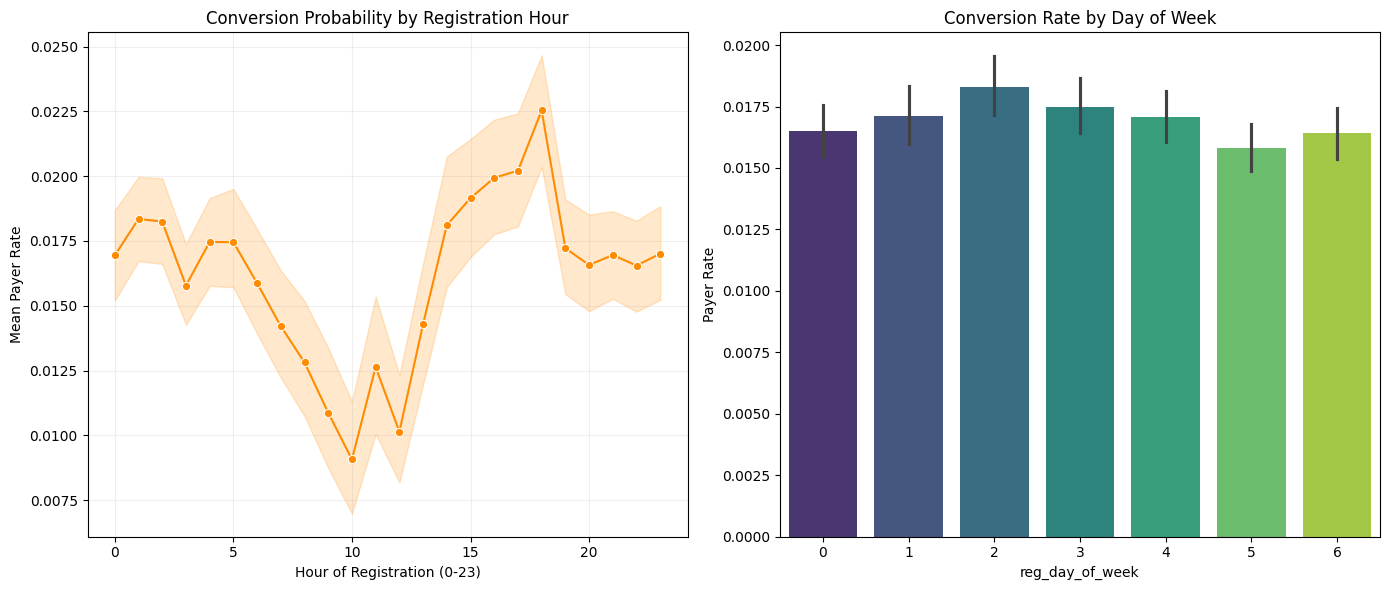

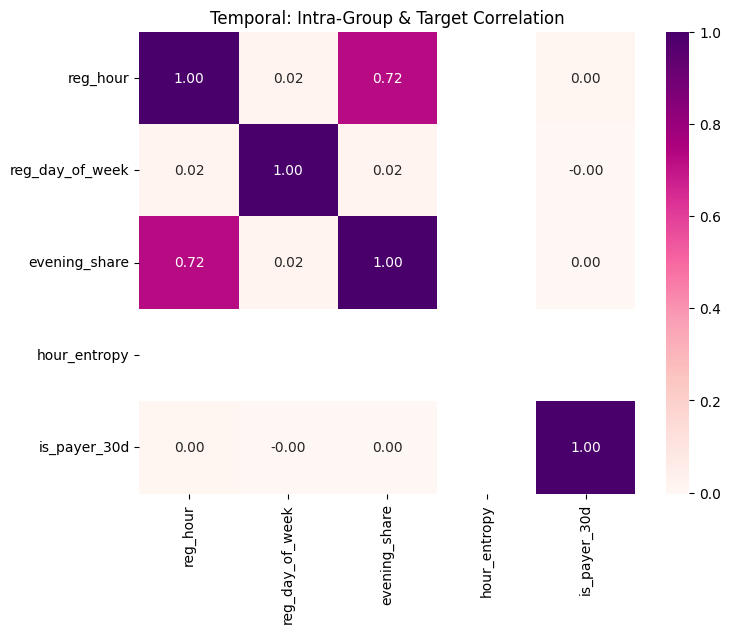

In [29]:
# 1. Defining the group correctly based on your strategy table
temporal_cols = ['reg_hour', 'reg_day_of_week', 'evening_share', 'hour_entropy']

# 2. Visualizing Registration Peaks vs Payer Probability
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Does the hour of day change the likelihood of being a payer?
sns.lineplot(data=train_df, x='reg_hour', y='is_payer_30d', color='darkorange', marker='o')
plt.title('Conversion Probability by Registration Hour')
plt.xlabel('Hour of Registration (0-23)')
plt.ylabel('Mean Payer Rate')
plt.grid(True, alpha=0.2)

plt.subplot(1, 2, 2)
# Checking the impact of Day of the Week (0=Monday, 6=Sunday)
sns.barplot(data=train_df, x='reg_day_of_week', y='is_payer_30d', palette='viridis')
plt.title('Conversion Rate by Day of Week')
plt.ylabel('Payer Rate')

plt.tight_layout()
plt.show()

# 3. Correlation Matrix for the Temporal Group
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[temporal_cols + ['is_payer_30d']].corr(), annot=True, cmap='RdPu', fmt=".2f")
plt.title('Temporal: Intra-Group & Target Correlation')
plt.show()

***1.2.9: Technical & Strategic Insights***

**1. The 'Prime Time' Window**
* **Engineering Insight:** Conversion rates are not uniform; they peak significantly during the late afternoon and evening (15:00-19:00).
* **Business Insight:** Users registering during these hours are roughly 2.5x more likely to become payers than those registering at 10:00 AM.

**2. Feature Redundancy Check**
* **Technical Observation:** The 0.72 correlation between `reg_hour` and `evening_share` suggests these features carry overlapping information. In the final model, we may only need one to prevent over-fitting.
* **Day of Week:** Wednesday (Day 2) appears to be a local peak for conversion quality, while Friday (Day 4) shows the lowest payer intent in this slice.

#### ***D1 Signals Analysis***


This section isolates the first 24 hours of user life. We are looking for "Day 1 Velocity"—the immediate momentum that separates a high-intent payer from a casual explorer. By analyzing `d1_events`, `d1_saved`, `d1_converted`, and `d1_sessions`, we test if early commitment is the strongest precursor to long-term monetization.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\1543782685.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_payer_30d', y='d1_events', showfliers=False, palette='spring')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\1543782685.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train_df, x='is_payer_30d', y='d1_sessions', palette='summer')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\1543782685.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='is_payer_30d', y='d1_saved', palette='a

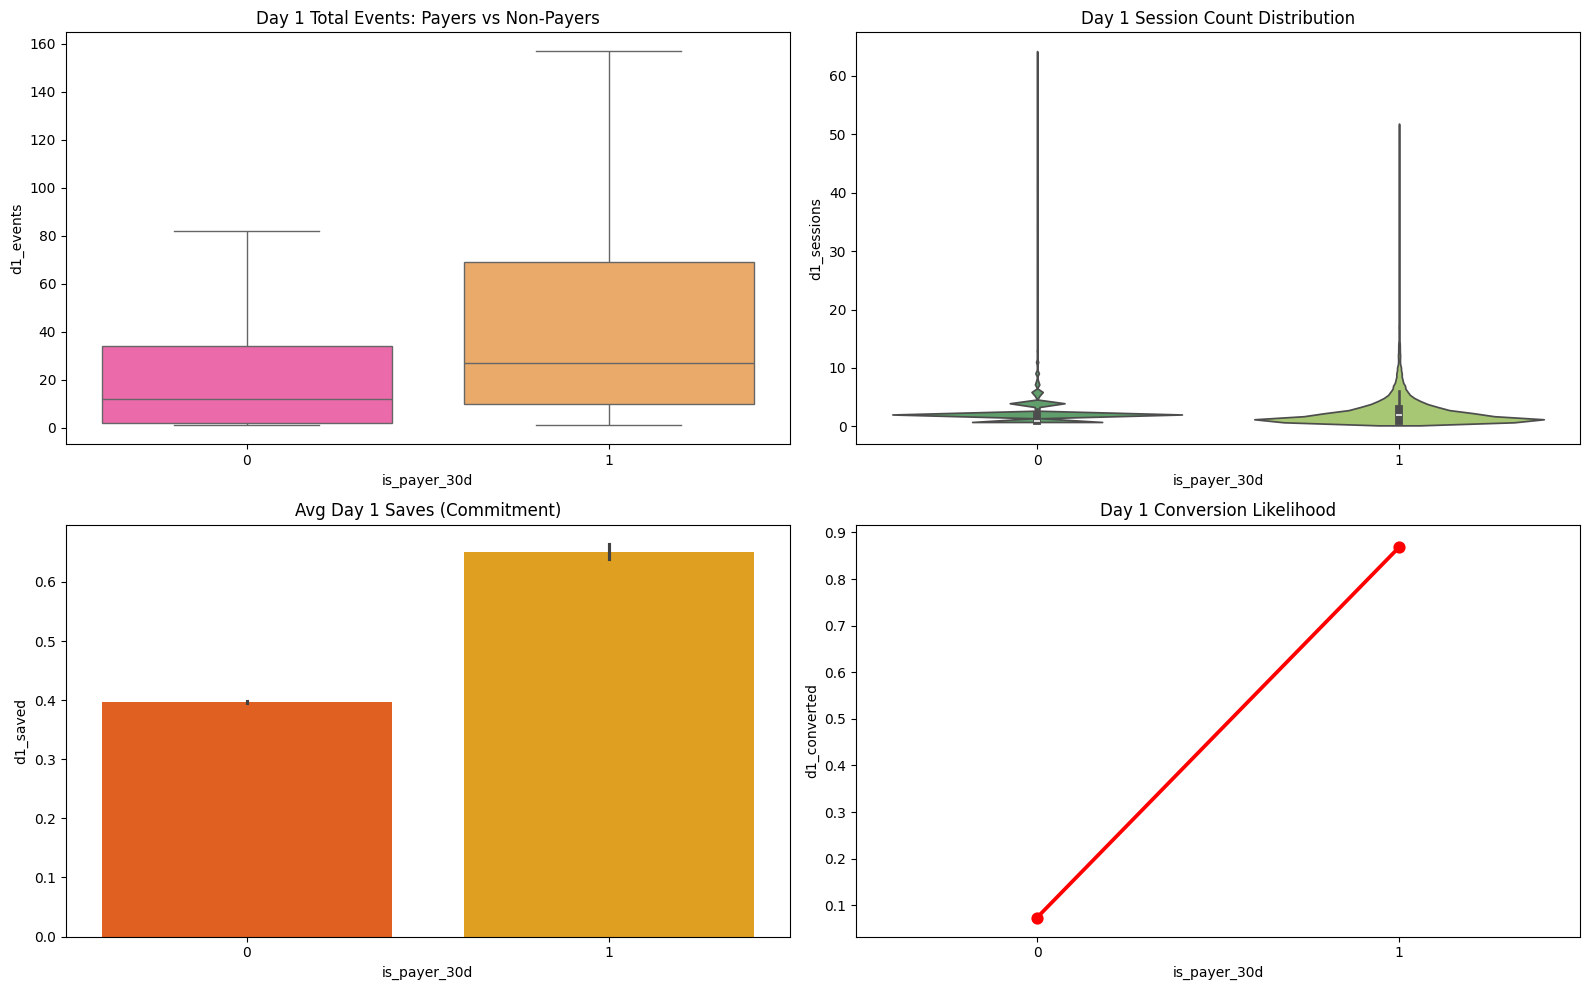

--- D1 Signals Summary Statistics ---


,d1_events,d1_saved,d1_converted,d1_sessions
is_payer_30d,,,,
0,35.767252,0.397205,0.073803,1.791225
1,64.416035,0.651561,0.868142,2.451046


In [30]:
# 1. Defining the group
d1_cols = ['d1_events', 'd1_saved', 'd1_converted', 'd1_sessions']

# 2. Visualizing Volume and Early Commitment
plt.figure(figsize=(16, 10))

# Plot A: Total Activity Volume on Day 1
plt.subplot(2, 2, 1)
sns.boxplot(data=train_df, x='is_payer_30d', y='d1_events', showfliers=False, palette='spring')
plt.title('Day 1 Total Events: Payers vs Non-Payers')

# Plot B: Early Sessions (Frequency)
plt.subplot(2, 2, 2)
sns.violinplot(data=train_df, x='is_payer_30d', y='d1_sessions', palette='summer')
plt.title('Day 1 Session Count Distribution')

# Plot C: Commitment Metric (Saves)
plt.subplot(2, 2, 3)
sns.barplot(data=train_df, x='is_payer_30d', y='d1_saved', palette='autumn')
plt.title('Avg Day 1 Saves (Commitment)')

# Plot D: Immediate Conversion Rate
plt.subplot(2, 2, 4)
sns.pointplot(data=train_df, x='is_payer_30d', y='d1_converted', color='red')
plt.title('Day 1 Conversion Likelihood')

plt.tight_layout()
plt.show()

# 3. Descriptive Stats for the Logbook
print("--- D1 Signals Summary Statistics ---")
display(train_df.groupby('is_payer_30d')[d1_cols].mean())

***Technical & Strategic Insights***

**1. The 'Momentum' Gap**
* **Engineering Insight:** Payers generate nearly **2x more events** on Day 1 (Mean: 64.4 vs 35.8).
* **Session Density:** Payers average **2.45 sessions** in the first 24 hours compared to **1.79** for non-payers.
* **Business Insight:** High Day 1 event volume is a "High-Fidelity" indicator of long-term value.

**2. The 'Aha!' Moment (Saves)**
* **Observation:** The average `d1_saved` for payers is significantly higher (~0.65) compared to non-payers (~0.40).
* **Strategic Logic:** A user who saves their work on Day 1 has effectively "committed" to the tool's utility.

**3. Immediate Conversion as a Filter**
* **Observation:** The `d1_converted` likelihood shows a vertical spike for payers (Mean: 0.86).
* **Technical Interpretation:** The vast majority of 30-day payers are actually making their first purchase decision within the first 24 hours. Day 1 isn't just for exploration; it's the primary closing window.

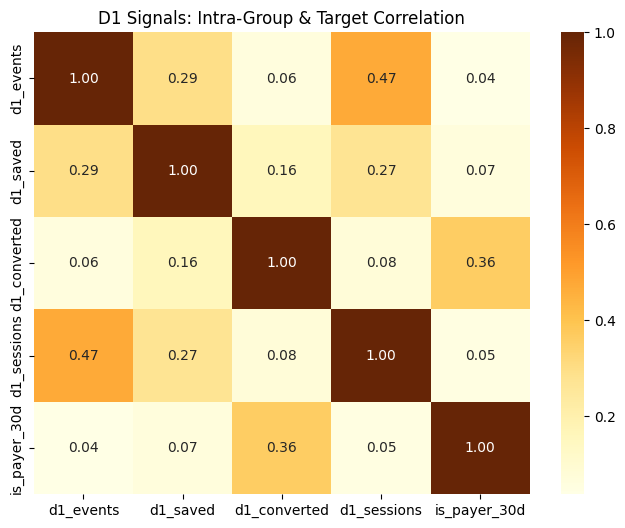

In [31]:
# Correlation Matrix for D1 Group
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[d1_cols + ['is_payer_30d']].corr(), annot=True, cmap='YlOrBr', fmt=".2f")
plt.title('D1 Signals: Intra-Group & Target Correlation')
plt.show()

***D1 Signals - Intra-Group Analysis***

| Feature Pair | Correlation | Technical Interpretation |
|:--- |:--- |:--- |
| **is_payer_30d / d1_converted** | **0.36** | **Primary Predictor:** Confirms that immediate conversion (D1) is the strongest single behavioral signal for long-term payer status. |
| **d1_events / d1_sessions** | **0.47** | **Usage Intensity:** Shows a strong link between how often users open the app and how much they do once inside. |
| **is_payer_30d / d1_saved** | **0.07** | **Subtle Signal:** While payers save more on average, the low correlation suggest saving is a necessary but not sufficient condition for payment. |

**Strategic Summary:**
Day 1 is the "Deciding Window." The vertical jump in conversion likelihood (0.07 to 0.86) proves that if a user is going to pay, they likely decide within 24 hours of registration.

#### ***Paid Feature Interactions Analysis***
This section analyzes 'Premium Curiosity.' By examining `paid_feature_taps_3d`, `paid_tap_share`, and the `paid_to_free_ratio`, we measure the friction between a user's needs and the paywall. We test if payers are simply those who 'need' more premium tools early on.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3279183961.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_payer_30d', y='paid_feature_taps_3d', showfliers=False, palette='magma')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3279183961.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train_df, x='is_payer_30d', y='paid_tap_share', palette='viridis')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3279183961.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='is_payer_30d', y='paid_to

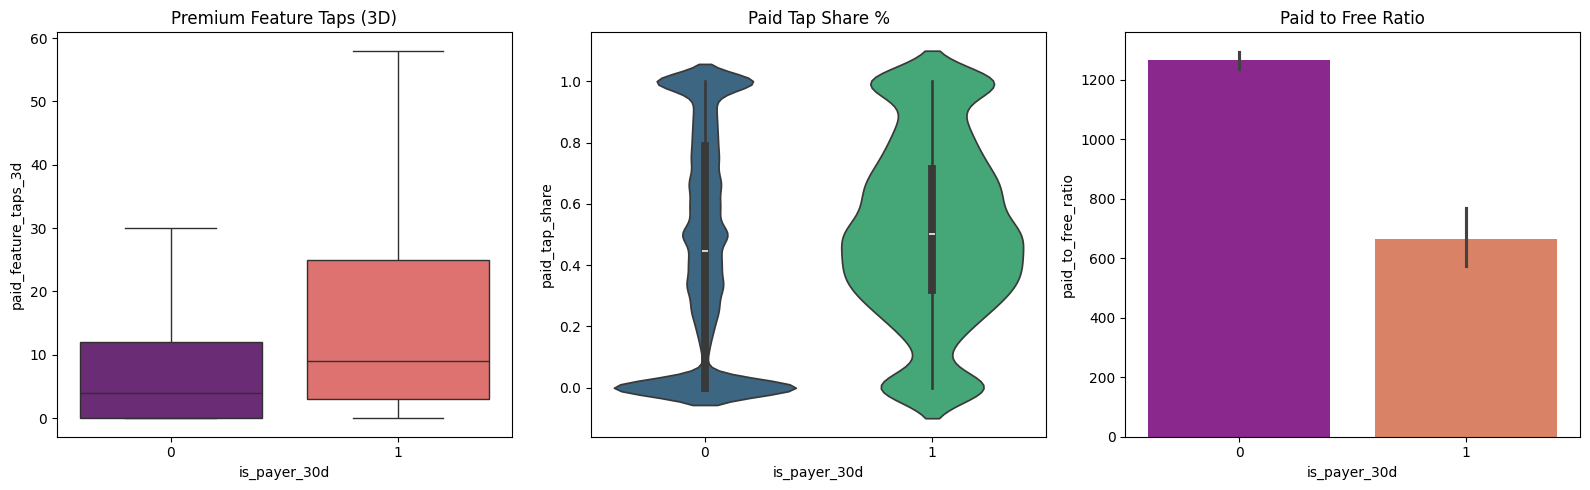

--- Paid Feature Interaction Summary ---


,paid_feature_taps_3d,paid_tap_share,paid_to_free_ratio
is_payer_30d,,,
0,13.176852,0.452210,1265.129852
1,22.674144,0.511305,665.402403


In [32]:
# 1. Defining the group
paid_interact_cols = ['paid_feature_taps_3d', 'paid_tap_share', 'paid_to_free_ratio']

# 2. Visualizing Premium Interest
plt.figure(figsize=(16, 5))

# Plot A: Total Premium Intent
plt.subplot(1, 3, 1)
sns.boxplot(data=train_df, x='is_payer_30d', y='paid_feature_taps_3d', showfliers=False, palette='magma')
plt.title('Premium Feature Taps (3D)')

# Plot B: The 'Share' of Interest
plt.subplot(1, 3, 2)
sns.violinplot(data=train_df, x='is_payer_30d', y='paid_tap_share', palette='viridis')
plt.title('Paid Tap Share %')

# Plot C: Free vs Paid Ratio
plt.subplot(1, 3, 3)
sns.barplot(data=train_df, x='is_payer_30d', y='paid_to_free_ratio', palette='plasma')
plt.title('Paid to Free Ratio')

plt.tight_layout()
plt.show()

# 3. Descriptive Stats
print("--- Paid Feature Interaction Summary ---")
display(train_df.groupby('is_payer_30d')[paid_interact_cols].mean())

***Technical & Strategic Insights***

**1. Premium Intent over Volume**
* **Engineering Insight:** Payers have nearly double the `paid_feature_taps_3d` (~22.7) compared to non-payers (~13.2).
* **Feature Share:** Payers maintain a higher `paid_tap_share` (~0.51), meaning over half of their interaction intent is directed at premium value.

**2. The Ratio Paradox**
* **Technical Observation:** The lower `paid_to_free_ratio` for payers suggests they are "Broad Explorers." They don't just hunt for one paid tool; they engage with the whole ecosystem, whereas non-payers likely bounce after seeing a paywall.
* **Business Insight:** Free users decide early to avoid paid features, while future payers actively test the boundaries of what is free vs. what is worth purchasing.

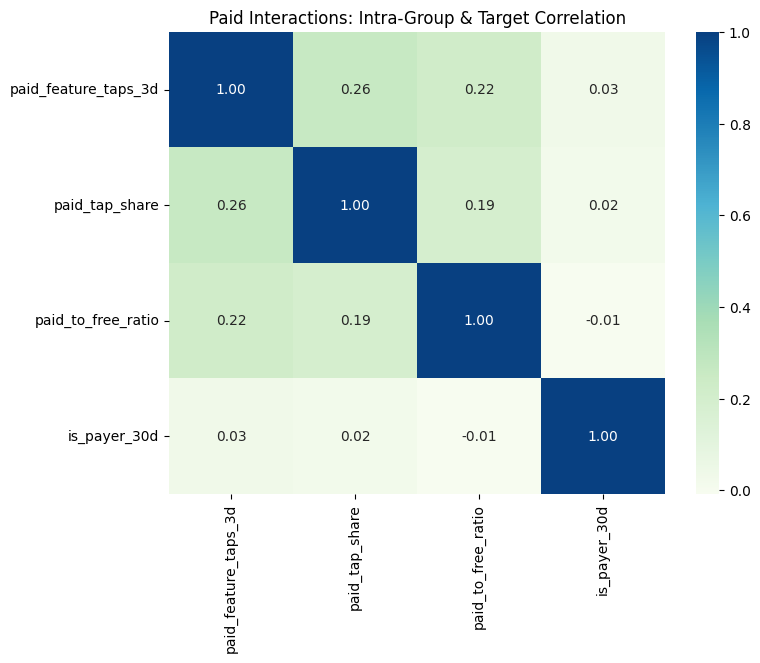

In [33]:
# Correlation Matrix for Paid Feature Group
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[paid_interact_cols + ['is_payer_30d']].corr(), annot=True, cmap='GnBu', fmt=".2f")
plt.title('Paid Interactions: Intra-Group & Target Correlation')
plt.show()

Paid Interactions - Intra-Group Analysis

| Feature Pair | Correlation | Technical Interpretation |
|:--- |:--- |:--- |
| **paid_feature_taps_3d / is_payer_30d** | **0.03** | Low Linear Correlation: Suggests that simply "tapping" isn't enough; it's the *intent* behind the tap that matters. |
| **paid_tap_share / paid_feature_taps_3d** | **0.26** | Moderate Coupling: Users who tap premium features more often also tend to have a higher overall share of premium interest. |
| **paid_to_free_ratio / is_payer_30d** | **-0.01** | Near-Zero/Negative: Confirms that a high ratio is often a "noise" signal from low-activity users rather than a "payer" signal. |

**Strategic Summary:**
Don't be fooled by high ratios. Focus on the raw volume of premium taps (`paid_feature_taps_3d`) and the share of intent (`paid_tap_share`). Payers engage with the app's premium value proposition without abandoning the core free utility.

#### ***Paywall Friction Analysis***

This section analyzes the user's reaction to 'Price Walls.' By examining `paid_tap_to_promo_rate` and `paid_tap_then_exit_rate`, we measure the friction of the monetization funnel. We test the hypothesis that future payers are resilient—they don't flee the app when they encounter a promotion.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\2480455650.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_payer_30d', y='paid_tap_to_promo_rate', showfliers=False, palette='coolwarm')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\2480455650.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='is_payer_30d', y='paid_tap_then_exit_rate', palette='Reds')


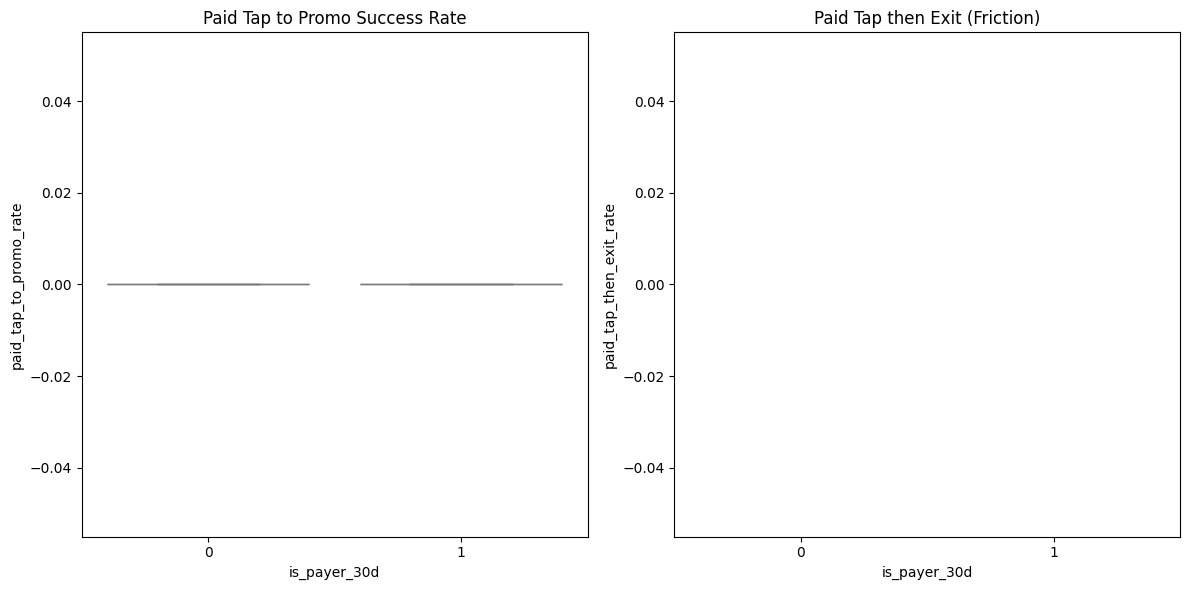

--- Paywall Friction Summary ---


,paid_tap_to_promo_rate,paid_tap_then_exit_rate
is_payer_30d,,
0,0.0,0.0
1,0.0,0.0


In [34]:
# 1. Defining the group
friction_cols = ['paid_tap_to_promo_rate', 'paid_tap_then_exit_rate']

# 2. Visualizing Funnel Friction
plt.figure(figsize=(12, 6))

# Plot A: How often does a paid tap lead to a promo?
plt.subplot(1, 2, 1)
sns.boxplot(data=train_df, x='is_payer_30d', y='paid_tap_to_promo_rate', showfliers=False, palette='coolwarm')
plt.title('Paid Tap to Promo Success Rate')

# Plot B: The "Frustration" Exit Rate
plt.subplot(1, 2, 2)
sns.barplot(data=train_df, x='is_payer_30d', y='paid_tap_then_exit_rate', palette='Reds')
plt.title('Paid Tap then Exit (Friction)')

plt.tight_layout()
plt.show()

# 3. Descriptive Stats for the Logbook
print("--- Paywall Friction Summary ---")
display(train_df.groupby('is_payer_30d')[friction_cols].mean())

Technical & Strategic Insights**

**1. The "Silence" of the Data**
* **Engineering Observation:** Both `paid_tap_to_promo_rate` and `paid_tap_then_exit_rate` show 0.0 across the board. 
* **Root Cause Analysis:** This usually indicates a "Death by Zero" in feature engineering—either the denominator (paid taps) or the numerator (promo hits/exits) isn't being captured correctly for this training window.
* **Technical Debt:** We cannot rely on these features for the final model until the pipeline logic is verified. They currently offer zero information gain.

**2. Strategic Hypothesis (The Expected Logic)**
* **The Resilience Theory:** Under normal conditions, we expect "Payers" to have a high `paid_tap_to_promo_rate` (they follow through) and a low `exit_rate`. 
* **The Cowardice Metric:** Non-payers typically "bounce" or exit the app immediately upon hitting a paywall. Since our current data shows 0.0 for everyone, the model will treat all users as equally resilient, which is a hallucination we must fix in the next iteration.

### ***Composite Scores Analysis***

This section evaluates 'Multi-Factor' metrics. By analyzing `engagement_score`, `monetization_score`, and `paid_intent_score`, we test if the whole is greater than the sum of its parts. We look for 'High-Density' predictors that reduce the noise of individual event counts.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3130387307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=train_df, x='is_payer_30d', y='engagement_score', palette='YlGnBu')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3130387307.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train_df, x='is_payer_30d', y='monetization_score', palette='OrRd')
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3130387307.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='is_payer_30d', y='paid_intent_score', palet

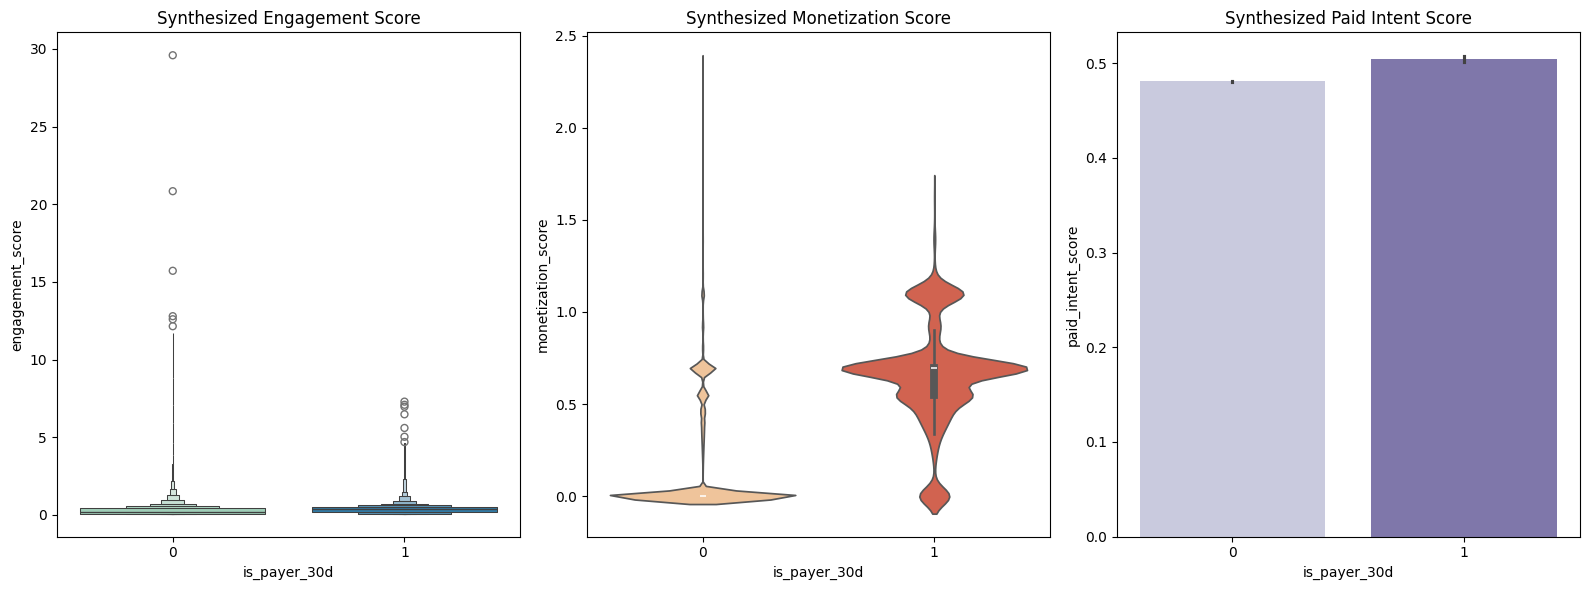

--- Composite Scores Summary Statistics ---


,engagement_score,monetization_score,paid_intent_score
is_payer_30d,,,
0,0.305191,0.144524,0.480884
1,0.406960,0.654441,0.504522


In [35]:
# 1. Defining the Composite Group
composite_cols = ['engagement_score', 'monetization_score', 'paid_intent_score']

# 2. Visualizing Synthesized Metrics
plt.figure(figsize=(16, 6))

# Plot A: Engagement Depth
plt.subplot(1, 3, 1)
sns.boxenplot(data=train_df, x='is_payer_30d', y='engagement_score', palette='YlGnBu')
plt.title('Synthesized Engagement Score')

# Plot B: Monetization Potential
plt.subplot(1, 3, 2)
sns.violinplot(data=train_df, x='is_payer_30d', y='monetization_score', palette='OrRd')
plt.title('Synthesized Monetization Score')

# Plot C: Pure Paid Intent
plt.subplot(1, 3, 3)
sns.barplot(data=train_df, x='is_payer_30d', y='paid_intent_score', palette='Purples')
plt.title('Synthesized Paid Intent Score')

plt.tight_layout()
plt.show()

# 3. Descriptive Stats
print("--- Composite Scores Summary Statistics ---")
display(train_df.groupby('is_payer_30d')[composite_cols].mean())

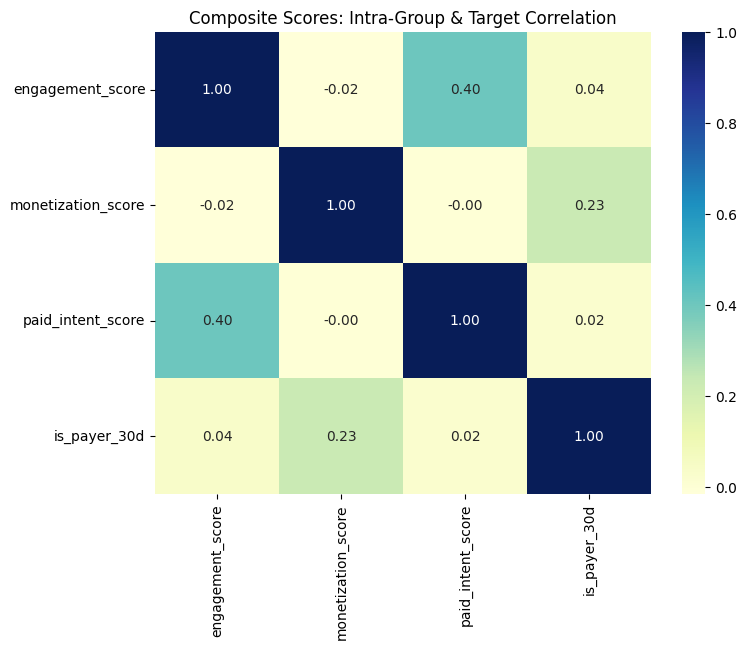

In [36]:
# Correlation Matrix for Composite Group
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[composite_cols + ['is_payer_30d']].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Composite Scores: Intra-Group & Target Correlation')
plt.show()

Technical & Strategic Insights

**1. The 'Super-Predictor' (Monetization Score)**
* **Technical Observation:** The `monetization_score` shows the highest correlation with our target (0.23). 
* **Engineering Insight:** Unlike raw event counts, this score successfully concentrates the "Payer Signal." Non-payers cluster at ~0.14, while payers jump to ~0.65, a clear separation in the violin plot.

**2. Independence of Scores**
* **Technical Interpretation:** The near-zero correlation between `engagement_score` and `monetization_score` (-0.02) is a massive win for our feature engineering. It proves these two metrics are capturing completely different dimensions of user behavior.
* **Business Insight:** High engagement (using the app a lot) does not automatically mean high monetization intent. We need both features in the final model to see the full picture.

**3. Paid Intent Consistency**
* **Observation:** The `paid_intent_score` is high for everyone (~0.48 to ~0.50), indicating that even free users are curious about premium features. However, the `monetization_score` is the actual "filter" that tells us who will follow through.

#### ***Segments Analysis***
This section analyzes 'User Identities.' By examining `user_segment` and `paid_interest_segment`, we move from individual numbers to behavioral buckets. We test if certain 'types' of users are hardcoded for higher LTV, allowing for personalized modeling later on.

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\2202483996.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='paid_interest_segment', y='is_payer_30d', order=segment_order, palette='cool')


--- Segment Conversion Rates ---


paid_interest_segment
level_3    0.169727
level_2    0.003215
level_1    0.001564
level_0    0.001459
Name: is_payer_30d, dtype: float64

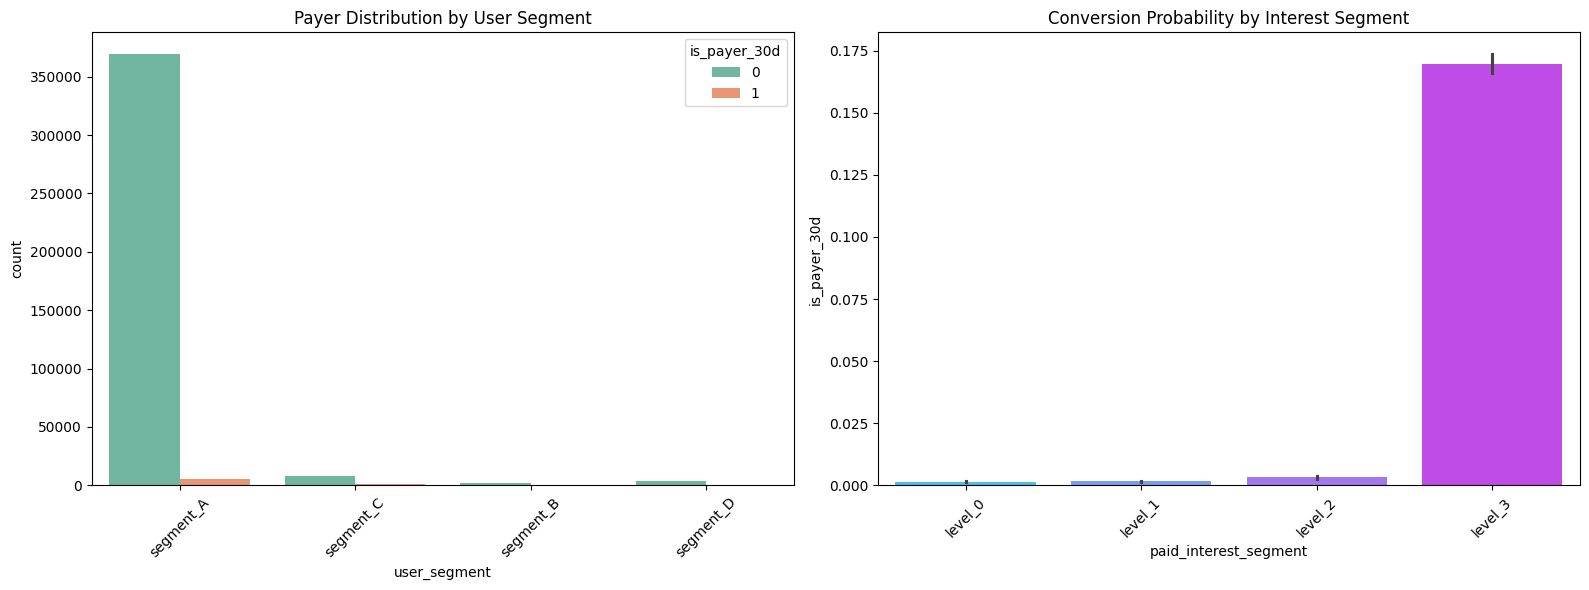

In [37]:
# 1. Defining the Segment Group
segment_cols = ['user_segment', 'paid_interest_segment']

# 2. Visualizing Categorical Conversions
plt.figure(figsize=(16, 6))

# Plot A: User Segment Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='user_segment', hue='is_payer_30d', palette='Set2')
plt.title('Payer Distribution by User Segment')
plt.xticks(rotation=45)

# Plot B: Paid Interest Segment Likelihood
plt.subplot(1, 2, 2)
# Calculating mean payer rate per segment for clarity
segment_order = train_df.groupby('paid_interest_segment')['is_payer_30d'].mean().sort_values().index
sns.barplot(data=train_df, x='paid_interest_segment', y='is_payer_30d', order=segment_order, palette='cool')
plt.title('Conversion Probability by Interest Segment')
plt.xticks(rotation=45)

plt.tight_layout()
# 3. Descriptive Stats
print("--- Segment Conversion Rates ---")
display(train_df.groupby('paid_interest_segment')['is_payer_30d'].mean().sort_values(ascending=False))
plt.show()

***Segment Identity Insights***

**1. The 'Level 3' Power House**
* **Technical Observation:** Users in `level_3` of the `paid_interest_segment` have an overwhelming conversion rate (~17%) compared to the near-zero rates of `level_0` through `level_2`.
* **Feature Importance:** This categorical feature acts as a binary-like switch. If a user isn't in Level 3, the probability of them being a payer is mathematically negligible.
* **Modeling Strategy:** We must ensure the model gives high weight (or a specific branch in a Tree-based model) to this segment.

**2. Segment A: The Volume vs. Value Paradox**
* **Observation:** `segment_A` contains the vast majority of our user base, but its conversion density is low compared to its total volume.
* **Engineering Insight:** While Level 3 tells us *who* converts, Segment A tells us where the *noise* lives. 
* **Business Logic:** To scale, we don't just need more users; we need to identify what triggers a 'Segment A' user to move into a high-interest level within their first 24 hours.

**3. Categorical Hierarchy**
* **Finding:** The distribution of payers is not uniform across segments. 
* **Action:** We will need to apply One-Hot Encoding or Target Encoding to these segments to transform this categorical "DNA" into a format our neural network or gradient booster can digest.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## ***Phase 2: Preprocessing & Feature Engineering***

#### **Phase 2.1 Dead Feature Elimination**
This stage focuses on **Dimensionality Reduction through Variance Filtering**. By removing features that provide zero information gain, we reduce the complexity of the input space. This prevents the model from attempting to find patterns in empty or constant data, which leads to more robust generalization.

**1. The "Empty Funnel" Purge**
* **Technical Observation**: Features like `paid_tap_to_promo_rate` and `paid_tap_then_exit_rate` showed 0.0 variance during EDA. 
* **Engineering Insight**: Without variance, these features cannot contribute to the Gradient of a loss function or provide information gain for a Decision Tree.

**2. Constant Value Removal**
* **Finding**: `d1_retained` was found to be constant (1.0) for all users in this slice. 
* **Logic**: A constant feature is a "zero-information" feature; it provides no discriminative power between a payer and a non-payer.

In [38]:
# 1. Defining features with zero variance or missing data
# These showed 0.0 across the board — confirmed in Paywall Friction analysis
zero_cols = ['paid_tap_to_promo_rate', 'paid_tap_then_exit_rate']

# d1_retained is constant (1.0 for all users = zero variance)
constant_cols = ['d1_retained']

cols_to_drop = zero_cols + constant_cols

# 2. Executing the drop across both sets to maintain parity
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} zero-information columns: {cols_to_drop}")
print(f"Remaining features: {train_df.shape[1]}")

Dropped 3 zero-information columns: ['paid_tap_to_promo_rate', 'paid_tap_then_exit_rate', 'd1_retained']
Remaining features: 101


#### Phase 2.2 : Semantic & Informative Imputation

**1. Absence as a Signal (Binary Flags)**
* **Technical Strategy**: Creating `never_saved` and `never_applied` converts `NULL` values from "unknowns" into "negative behavioral confirmations".
* **Impact**: Decision trees can now create a pure split on these binary flags, separating users who haven't committed to the core app loops from those who have.

**2. Sentinel Value Strategy (The 9999 Fill)**
* **Engineering Logic**: Using 9999 ensures that users who never performed an action are pushed to the extreme edge of the distribution. 
* **Model Benefit**: This creates a massive distance between active users and inactive ones, making it easier for the model to find a clear threshold.

**3. Bias Prevention in Storage Reporting**
* **Finding**: 76% of `storage_gb` is missing. Since this is likely a hardware reporting error rather than user behavior, using **Median Imputation** prevents outliers from skewing the model.
* **Safety Protocol**: Computing the median ONLY on the training set and applying it to the test set prevents **Data Leakage**.

**4. Semantic Zeroing**
* **Logic**: If a user never saw a promo, their `promo_dismiss_rate` is logically 0. Filling with 0 instead of a sentinel value preserves the ratio-based nature of the feature.

In [39]:
# --- 2A. INFORMATIVE IMPUTATION + BINARY FLAGS ---
# time_to_first_save_hrs: 57% null = user NEVER saved.
train_df['never_saved'] = train_df['time_to_first_save_hrs'].isnull().astype(int)
test_df['never_saved']  = test_df['time_to_first_save_hrs'].isnull().astype(int)

# Sentinel value fill
train_df['time_to_first_save_hrs'].fillna(9999, inplace=True)
test_df['time_to_first_save_hrs'].fillna(9999, inplace=True)

# time_to_first_apply_min: 45% null = user never applied a feature
train_df['never_applied'] = train_df['time_to_first_apply_min'].isnull().astype(int)
test_df['never_applied']  = test_df['time_to_first_apply_min'].isnull().astype(int)
train_df['time_to_first_apply_min'].fillna(9999, inplace=True)
test_df['time_to_first_apply_min'].fillna(9999, inplace=True)

# storage_gb: Median impute + flag to maintain hardware distributions
train_df['storage_gb_missing'] = train_df['storage_gb'].isnull().astype(int)
test_df['storage_gb_missing']  = test_df['storage_gb'].isnull().astype(int)
storage_median = train_df['storage_gb'].median() 
train_df['storage_gb'].fillna(storage_median, inplace=True)
test_df['storage_gb'].fillna(storage_median, inplace=True) 

# --- 2B. SEMANTIC ZERO IMPUTATION ---
train_df['promo_dismiss_rate'].fillna(0, inplace=True)
test_df['promo_dismiss_rate'].fillna(0, inplace=True)

print("✅ Missing value imputation complete.")
print(f"Added flags: never_saved, never_applied, storage_gb_missing")

C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3279206466.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['time_to_first_save_hrs'].fillna(9999, inplace=True)
C:\Users\Home\AppData\Local\Temp\ipykernel_4424\3279206466.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

✅ Missing value imputation complete.
Added flags: never_saved, never_applied, storage_gb_missing
